In [1]:
# decision_tree

In [2]:
# import libraries

# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# import for distance calculations
#pip install geopy
from geopy import distance
import math

# import scipy for statistical analysis in eda
#!pip install scipy
from scipy import stats

# import datetime to set timestamp on pdf report
from datetime import datetime, date, timedelta, time


from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

print("All required libraries installed")

All required libraries installed


In [3]:
# data file names

data_file_hurr = "../data/ibtracs.NA.list.v04r01.csv"

data_file_gas = "../data/aaa_fl_metros_wayback_2022_2025.csv"
#"../data/gas_coordinates.csv"

data_file_coast = "../data/Gulf_Coast_Coords.csv"

data_file_metro_loc = "../data/gas_coordinates.csv"

# import file loading functions
from file_load import *

# import data files
hurr_file_chk = input('Is hurricane data file downloaded to data folder? (y/n) ')
if hurr_file_chk == 'y':
    hurr_data = df_import(data_file_hurr)
else:
    url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.NA.list.v04r01.csv'
    hurr_data = pd.read_csv(url)

hurr_data.name = 'hurr_data'

gas_data = df_import(data_file_gas)
gas_data.name = 'gas_data'

coast_pt_data = df_import(data_file_coast)

metro_loc_data = coord_import(data_file_metro_loc)

C:\Users\eenoo\Downloads\CSCI_5502\Project\src\file_load.py:6: DtypeWarning: Columns (0: SEASON, 1: NUMBER, 2: BASIN, 3: LAT, 4: LON, 5: DIST2LAND, 6: USA_LAT, 7: USA_LON, 8: USA_WIND, 9: USA_PRES, 10: STORM_SPEED, 11: STORM_DIR) have mixed types. Specify dtype option on import or set low_memory=False.
  pri_data = pd.read_csv(datafile)


Successfully loaded ../data/ibtracs.NA.list.v04r01.csv
Successfully loaded ../data/aaa_fl_metros_wayback_2022_2025.csv
Successfully loaded ../data/Gulf_Coast_Coords.csv
Successfully loaded ../data/gas_coordinates.csv


In [4]:
# import data cleaning functions
from clean import *

# Clean hurricane data and generate data frames for cleaned hurricane data, list of hurricanes, and summary list of hurricanes with maximum storm category observed
# Generates data frames with ALL data and a set of filtered data frames for "recent" (2022-2025)
hurr_data_redux, hurr_list, hurr_sum_list, hurr_data_redux_rec, hurr_list_rec, hurr_sum_list_rec, hurr_data_redux_rec_hur = hurr_clean(hurr_data)

# Name output data frames
hurr_data_redux.name = 'hurr_data_redux'
hurr_list.name = 'hurr_list'
hurr_sum_list.name = 'hurr_sum_list'
hurr_data_redux_rec.name = 'hurr_data_redux_rec'
hurr_list_rec.name = 'hurr_list_rec'
hurr_sum_list_rec.name = 'hurr_sum_list_rec'
hurr_data_redux_rec_hur.name = 'hurr_data_redux_rec_hur'

# Clean gas station data and generate data frame for cleaned gas station data
gas_data_redux = gas_clean(gas_data)
gas_data_redux.name = 'gas_data_redux'

Cleaning hurr_data
          Unit
SID           
SEASON    Year
NUMBER        
BASIN         
SUBBASIN      
(174, 1)
Data table columns reduced to 47
Hurricane data cleaning complete
Cleaning gas_data
Gas data cleaning complete


In [5]:
# import model data functions
from model_data_prep1 import *

from model_data_gen import *

from modeling_fcns import *

from dec_tree_fcns import *

from rand_forest_fcns import *

In [6]:
# additional formatting of hurricane data
hurr_mod_data = hurr_data_prep(hurr_data_redux_rec_hur)

In [7]:
# generate data set with categorized / binary data for each day of storm activity

storm_data_all, model_data = model_dataset(hurr_mod_data, gas_data_redux, metro_loc_data)
model_data.head()

Pensacola selected
Tallahassee selected
Tampa-St. Petersburg-Clearwater selected
Fort Myers-Cape Coral selected
Miami selected
West Palm Beach-Boca Raton selected
Melbourne-Titusville selected
Daytona Beach selected
Jacksonville selected


,md_key,USA_SSHS,STORM_LOC_BIN,CD2LAND,CD2LANDFALL,CD2METRO,INBOUND,CD2OIL,OIL_THT,STORM_LEN,month_no,buy_avg,buy_day
0,2022-06-27-Pensacola,-3,1,2,2,2,1,2,0,0,6,0,0
1,2022-06-28-Pensacola,-3,1,2,2,2,1,2,0,1,6,0,0
2,2022-06-29-Pensacola,-3,1,1,1,2,1,2,0,2,6,0,0
3,2022-06-30-Pensacola,-3,1,1,1,2,0,2,0,3,6,0,0
4,2022-07-01-Pensacola,0,1,1,1,2,0,2,0,4,7,0,0


In [8]:
storm_data_all.head()

,date_key,METRO,USA_SSHS,DIST2METRO,BEAR2METRO,STORM_LOC,STORM_LOC_BIN,INBOUND,DIST2OIL,OIL_THT,...,md_key,month_no,storm_30d_avg_reg,storm_30d_avg_mid,storm_30d_avg_pre,storm_pct_avg_reg,storm_pct_avg_mid,storm_pct_avg_pre,buy_avg,buy_day
0,2022-06-27,Pensacola,-3,4542,308,ATL,1,1,4923,0,...,2022-06-27-Pensacola,6,4.576,4.921,5.247,-0.007,-0.000,0.003,0,0
1,2022-06-28,Pensacola,-3,3941,311,ATL,1,1,4290,0,...,2022-06-28-Pensacola,6,4.576,4.921,5.247,-0.012,-0.005,-0.002,0,0
2,2022-06-29,Pensacola,-3,3039,318,ATL,1,1,3310,0,...,2022-06-29-Pensacola,6,4.576,4.921,5.247,-0.014,-0.005,-0.003,0,0
3,2022-06-30,Pensacola,-3,2526,327,ATL,1,0,2697,0,...,2022-06-30-Pensacola,6,4.576,4.921,5.247,-0.016,-0.009,-0.005,0,0
4,2022-07-01,Pensacola,0,2264,343,ATL,1,0,2262,0,...,2022-07-01-Pensacola,7,4.576,4.921,5.247,-0.019,-0.012,-0.009,0,0


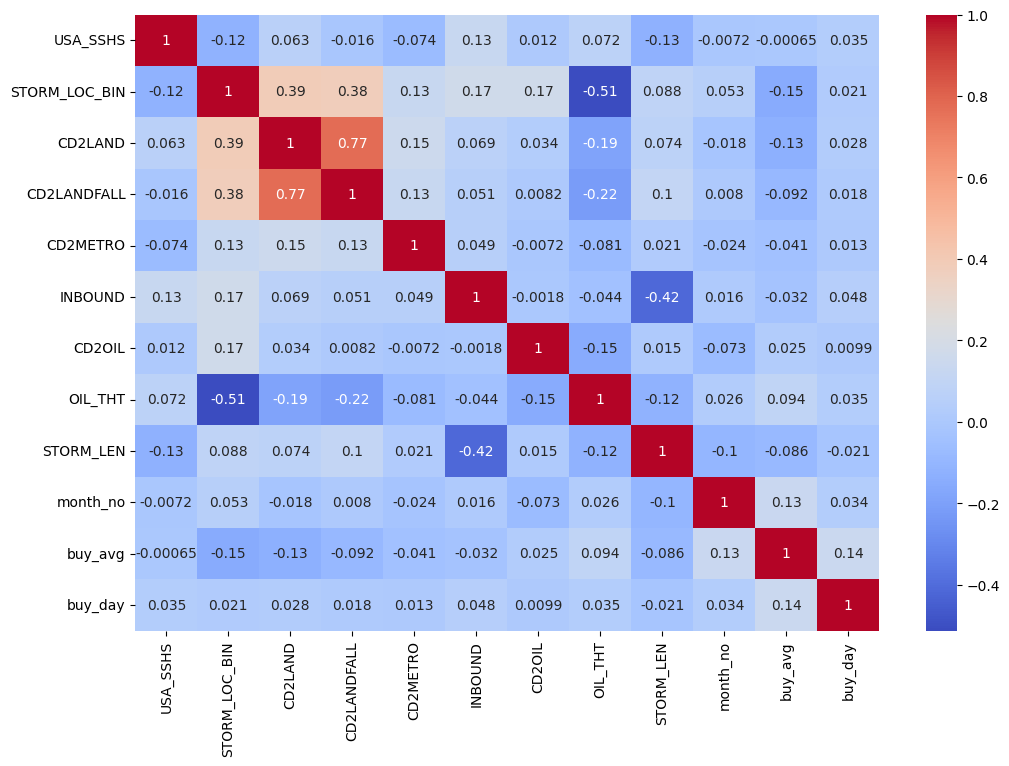

In [9]:
# Correlation heat map to look for dependences that should be avoided
X = model_data.drop(columns = 'md_key')
corr = X.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [10]:
class_list = ['not buy','buy']

Evaluate full model data set with no restrictions on max tree level (set to None), min leaf samples (set to 1), or max leaf nodes (set to None)

        Features  Importances
9       month_no     0.394747
8      STORM_LEN     0.226754
0       USA_SSHS     0.147165
3    CD2LANDFALL     0.085485
2        CD2LAND     0.081274
5        INBOUND     0.040915
7        OIL_THT     0.013191
4       CD2METRO     0.010468
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



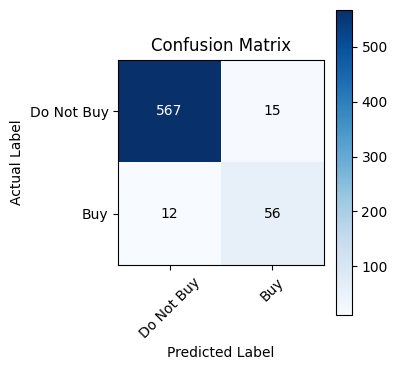

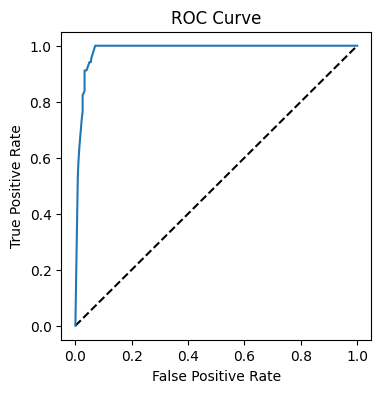

AUC: 0.9847508591065293


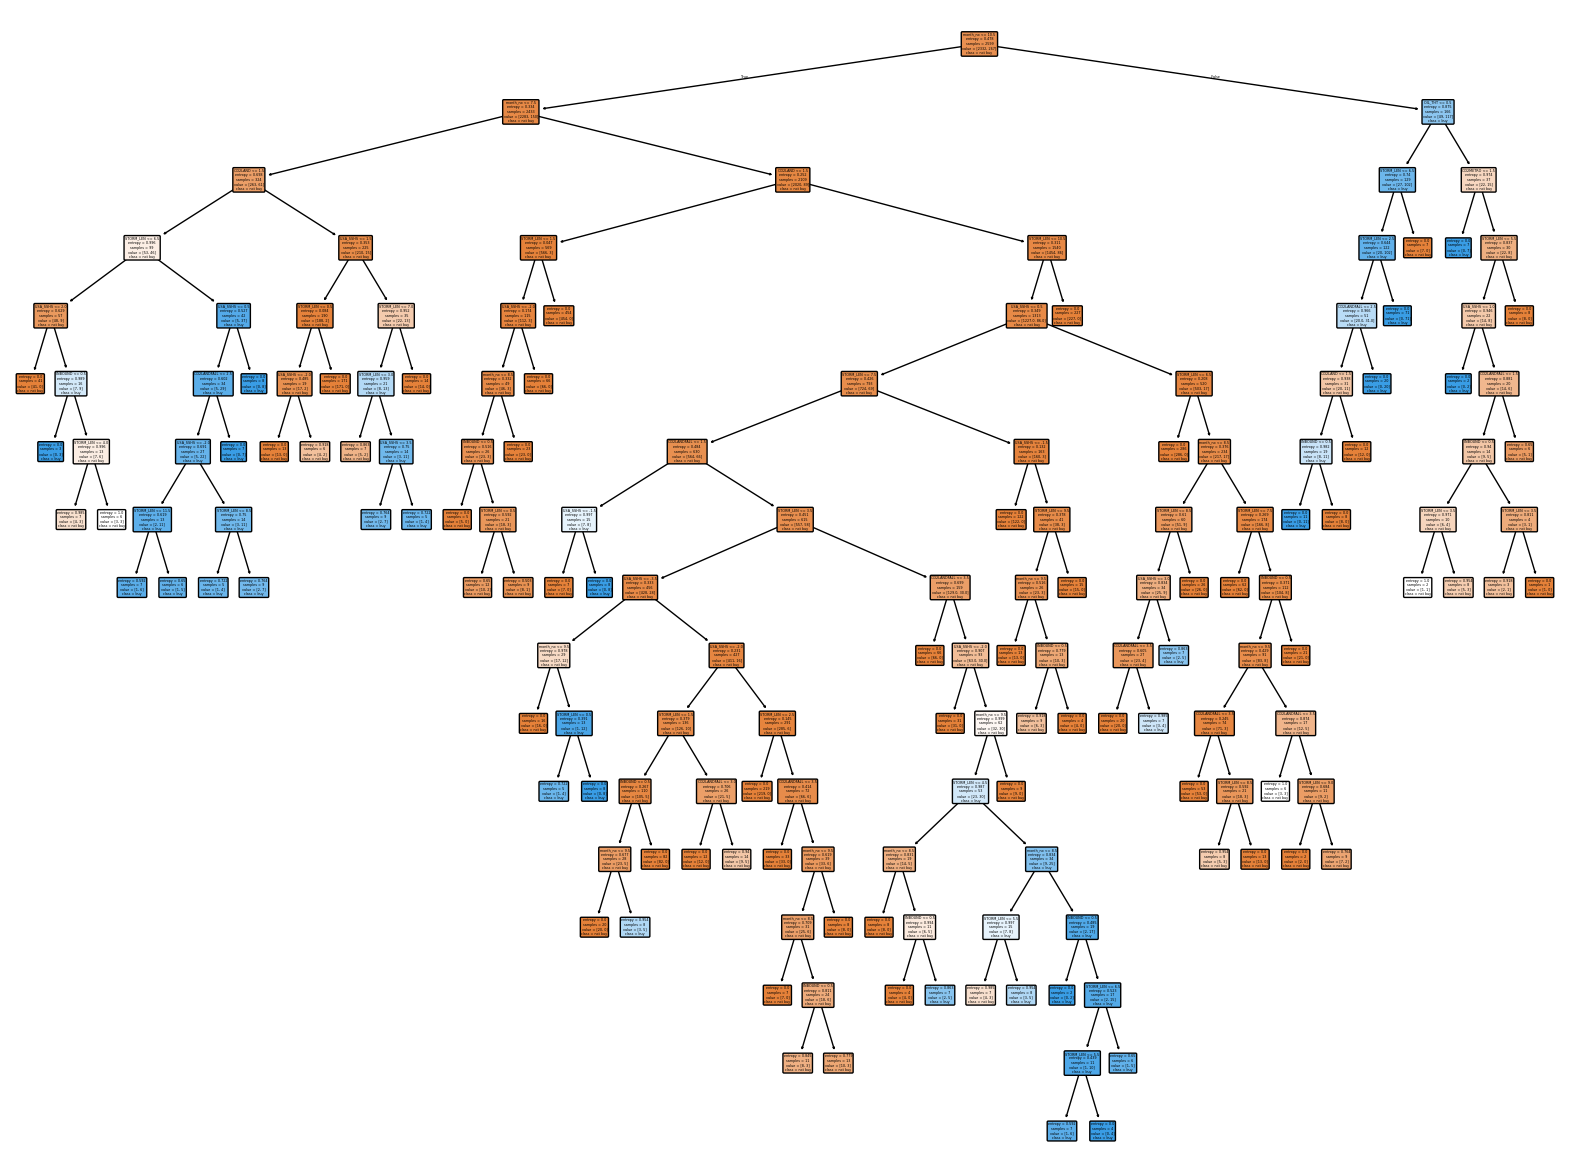

In [11]:
model_all_avg = model_data[['USA_SSHS', 'STORM_LOC_BIN', 'CD2LAND', 'CD2LANDFALL', 'CD2METRO', 'INBOUND', 'CD2OIL', 'OIL_THT', 'STORM_LEN',	'month_no',	'buy_avg']]

dec_tree_std(model_all_avg, 'buy_avg', class_list, 0.2, None, 1, None)

This model is clearly overfitted. It will be used for parametric analysis on the decision tree hyperparameters (max level, min leaf samples, and max leaf nodes) to identify a target range of values that support good model performance. 

        Features  Importances
8      STORM_LEN     0.347978
0       USA_SSHS     0.214889
9       month_no     0.161672
5        INBOUND     0.111032
3    CD2LANDFALL     0.080894
2        CD2LAND     0.038855
7        OIL_THT     0.037336
1  STORM_LOC_BIN     0.007343
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.012307692307692308
R-squared:  0.2602077109119365
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       639
           1       0.71      0.45      0.56        11

    accuracy                           0.99       650
   macro avg       0.85      0.73      0.77       650
weighted avg       0.99      0.99      0.99       650



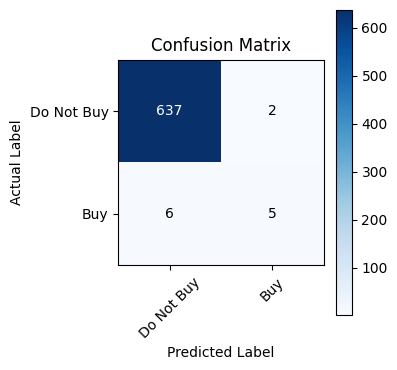

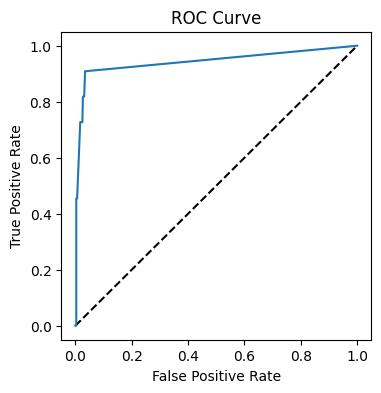

AUC: 0.9428794992175275


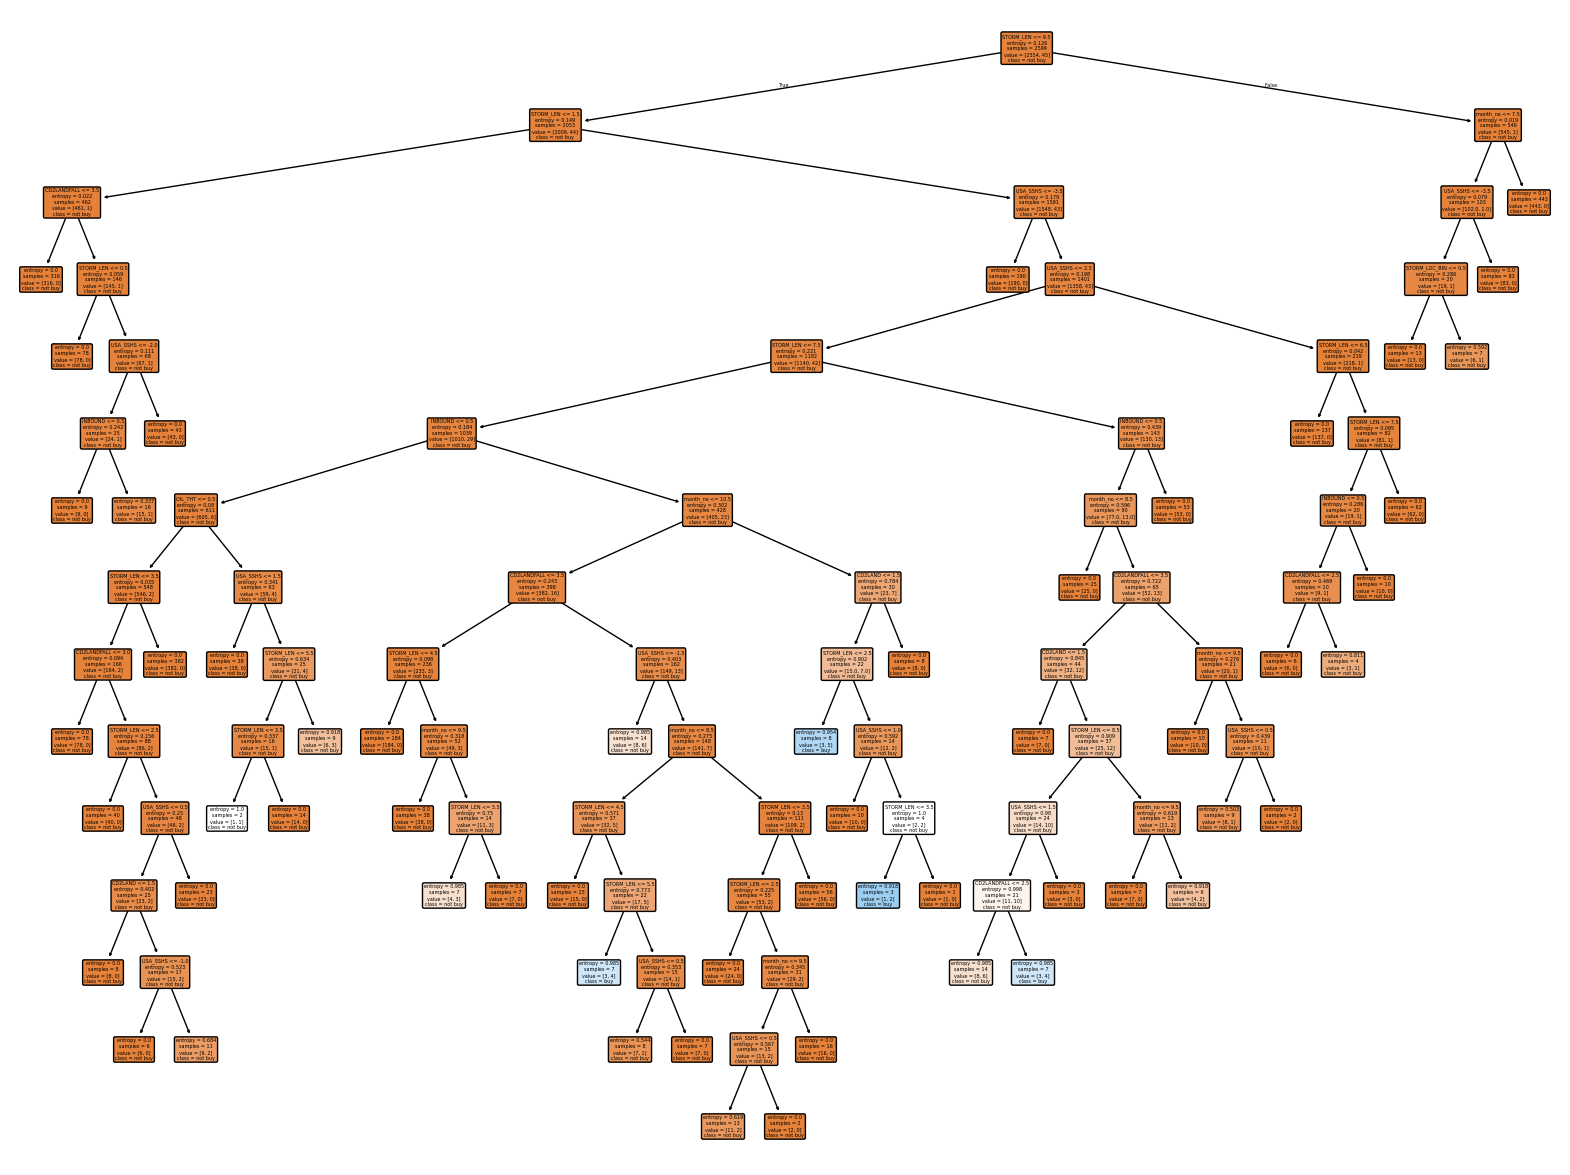

In [12]:
model_all_day = model_data[['USA_SSHS', 'STORM_LOC_BIN', 'CD2LAND', 'CD2LANDFALL', 'CD2METRO', 'INBOUND', 'CD2OIL', 'OIL_THT', 'STORM_LEN',	'month_no',	'buy_day']]

dec_tree_std(model_all_day, 'buy_day', class_list, 0.2, None, 1, None)

The results on the model using the 'buy_day' data are much weaker than the model using 'buy_avg', so the choice is made to focus on models using 'buy_avg'.

Model: model_all_avg (1) / Response: buy_avg
Model: model_all_avg (1) / Response: buy_avg / max level: 2 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no      0.96079
7        OIL_THT      0.03921
1  STORM_LOC_BIN      0.00000
0       USA_SSHS      0.00000
2        CD2LAND      0.00000
3    CD2LANDFALL      0.00000
5        INBOUND      0.00000
4       CD2METRO      0.00000
6         CD2OIL      0.00000
8      STORM_LEN      0.00000
Mean Squared Error:  0.08153846153846153
R-squared:  0.1295229431978978
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       582
           1       0.73      0.35      0.48        68

    accuracy                           0.92       650
   macro avg       0.83      0.67      0.72       650
weighted avg       0.91      0.92      0.91       650



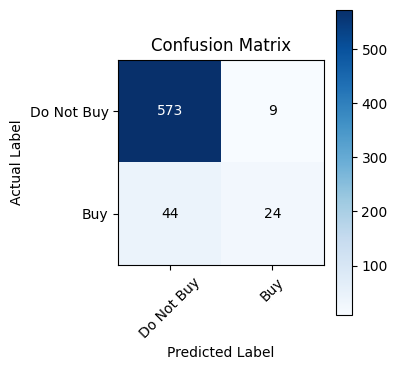

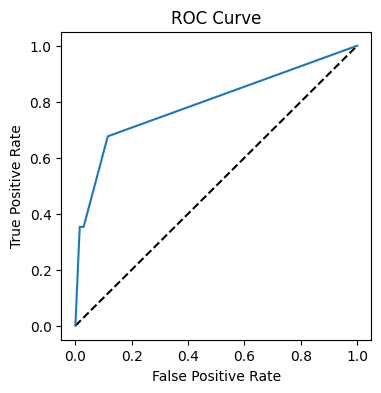

AUC: 0.7935364867596524
Model: model_all_avg (1) / Response: buy_avg / max level: 4 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.576695
8      STORM_LEN     0.173419
2        CD2LAND     0.127195
0       USA_SSHS     0.051533
6         CD2OIL     0.028947
7        OIL_THT     0.023535
4       CD2METRO     0.018677
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
3    CD2LANDFALL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



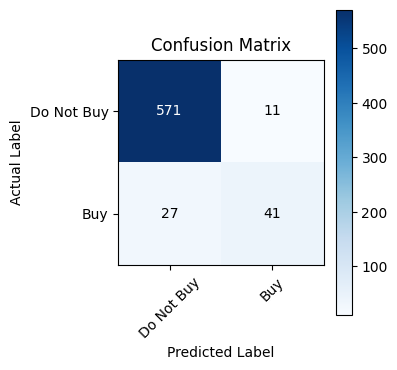

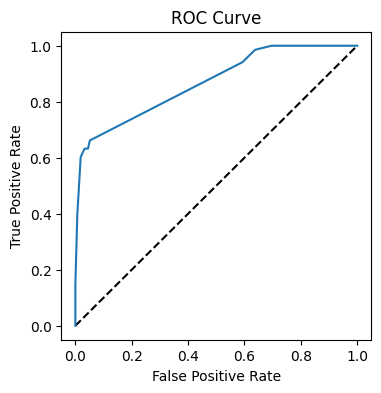

AUC: 0.8673564786739438
Model: model_all_avg (1) / Response: buy_avg / max level: 6 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.471188
8      STORM_LEN     0.217269
2        CD2LAND     0.117167
0       USA_SSHS     0.097534
3    CD2LANDFALL     0.027849
6         CD2OIL     0.023390
7        OIL_THT     0.019017
4       CD2METRO     0.015092
5        INBOUND     0.008987
1  STORM_LOC_BIN     0.002508
Mean Squared Error:  0.04923076923076923
R-squared:  0.47442894683646664
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       582
           1       0.86      0.63      0.73        68

    accuracy                           0.95       650
   macro avg       0.91      0.81      0.85       650
weighted avg       0.95      0.95      0.95       650



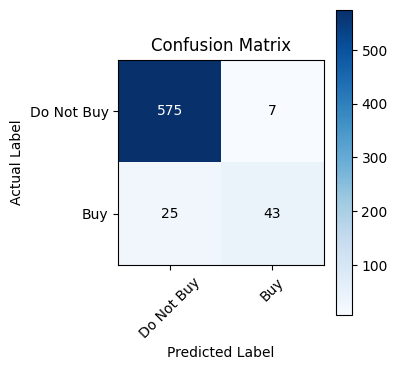

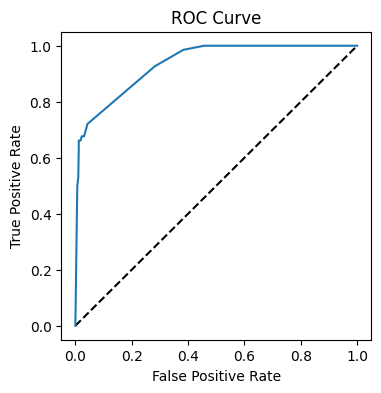

AUC: 0.9354533050333536
Model: model_all_avg (1) / Response: buy_avg / max level: 8 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.424613
8      STORM_LEN     0.252125
2        CD2LAND     0.104480
0       USA_SSHS     0.099257
5        INBOUND     0.046355
3    CD2LANDFALL     0.042738
7        OIL_THT     0.016975
4       CD2METRO     0.013457
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.046153846153846156
R-squared:  0.5072771376591874
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       582
           1       0.88      0.65      0.75        68

    accuracy                           0.95       650
   macro avg       0.92      0.82      0.86       650
weighted avg       0.95      0.95      0.95       650



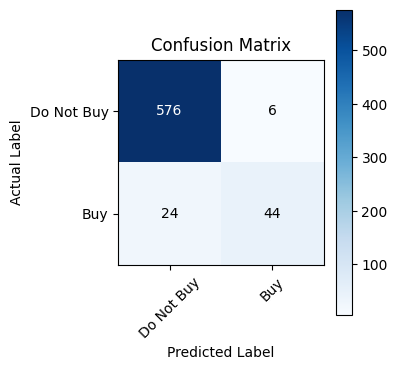

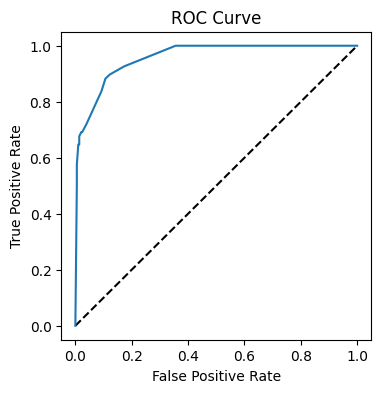

AUC: 0.9585102082069941
Model: model_all_avg (1) / Response: buy_avg / max level: 10 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.400155
8      STORM_LEN     0.199103
0       USA_SSHS     0.162866
3    CD2LANDFALL     0.086144
2        CD2LAND     0.078899
5        INBOUND     0.028693
6         CD2OIL     0.017956
7        OIL_THT     0.014599
4       CD2METRO     0.011585
1  STORM_LOC_BIN     0.000000
Mean Squared Error:  0.04461538461538461
R-squared:  0.5237012330705478
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       582
           1       0.83      0.72      0.77        68

    accuracy                           0.96       650
   macro avg       0.90      0.85      0.87       650
weighted avg       0.95      0.96      0.95       650



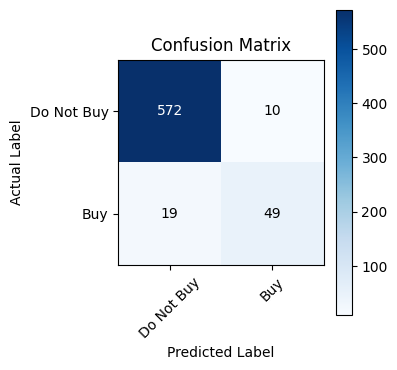

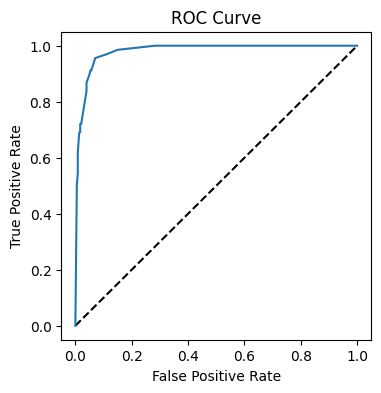

AUC: 0.9804174247018396
Model: model_all_avg (1) / Response: buy_avg / max level: 12 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.382338
8      STORM_LEN     0.215844
0       USA_SSHS     0.151750
3    CD2LANDFALL     0.098441
2        CD2LAND     0.073514
5        INBOUND     0.036987
6         CD2OIL     0.016730
7        OIL_THT     0.013602
4       CD2METRO     0.010795
1  STORM_LOC_BIN     0.000000
Mean Squared Error:  0.043076923076923075
R-squared:  0.5401253284819083
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.81      0.80        68

    accuracy                           0.96       650
   macro avg       0.88      0.89      0.89       650
weighted avg       0.96      0.96      0.96       650



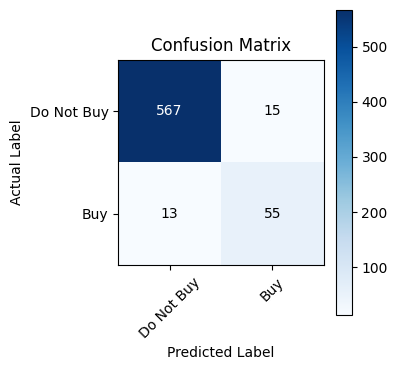

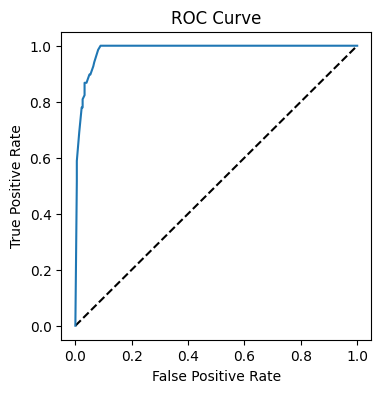

AUC: 0.9845992520719627
Model: model_all_avg (1) / Response: buy_avg / max level: 14 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.395080
8      STORM_LEN     0.226140
0       USA_SSHS     0.147289
3    CD2LANDFALL     0.095547
2        CD2LAND     0.071353
5        INBOUND     0.040911
7        OIL_THT     0.013203
4       CD2METRO     0.010477
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



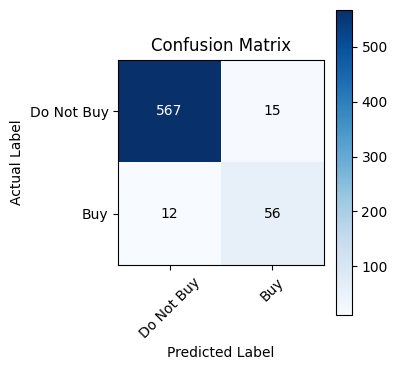

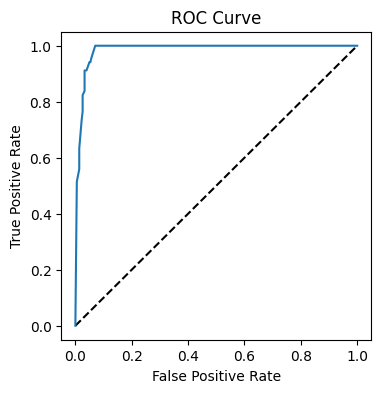

AUC: 0.9854078229229836
Model: model_all_avg (1) / Response: buy_avg / max level: 16 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.394747
8      STORM_LEN     0.210530
0       USA_SSHS     0.147165
3    CD2LANDFALL     0.084947
2        CD2LAND     0.081812
5        INBOUND     0.040915
6         CD2OIL     0.016225
7        OIL_THT     0.013191
4       CD2METRO     0.010468
1  STORM_LOC_BIN     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



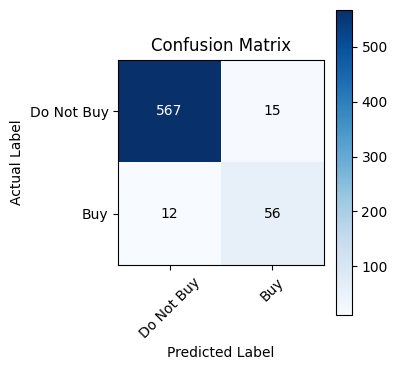

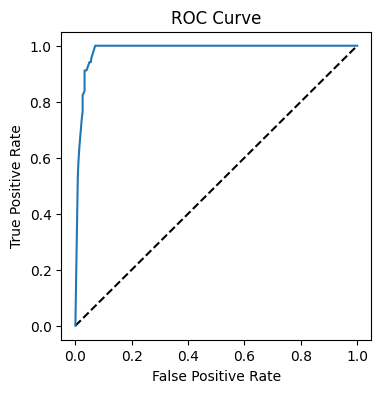

AUC: 0.9847508591065293
Model: model_all_avg (1) / Response: buy_avg / max level: 18 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.394747
8      STORM_LEN     0.226754
0       USA_SSHS     0.147165
3    CD2LANDFALL     0.085485
2        CD2LAND     0.081274
5        INBOUND     0.040915
7        OIL_THT     0.013191
4       CD2METRO     0.010468
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



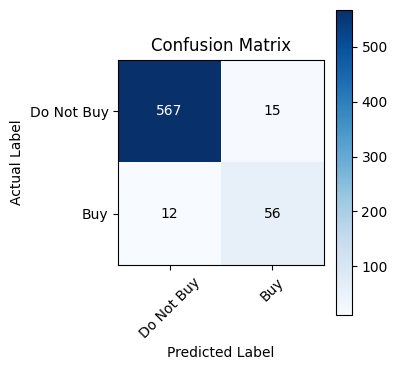

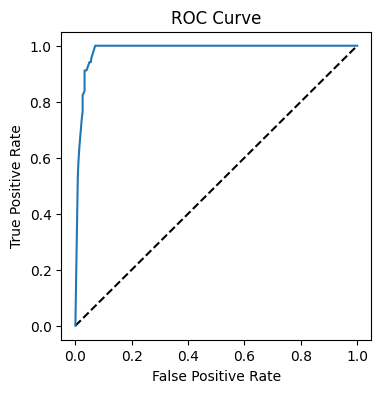

AUC: 0.9847508591065293
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 2 / max leaf node: None
        Features  Importances
9       month_no     0.394932
8      STORM_LEN     0.226391
0       USA_SSHS     0.147234
3    CD2LANDFALL     0.085525
2        CD2LAND     0.081312
5        INBOUND     0.040935
7        OIL_THT     0.013198
4       CD2METRO     0.010473
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



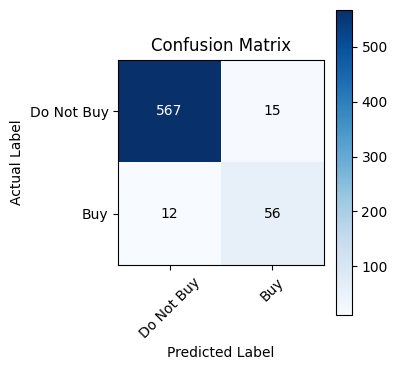

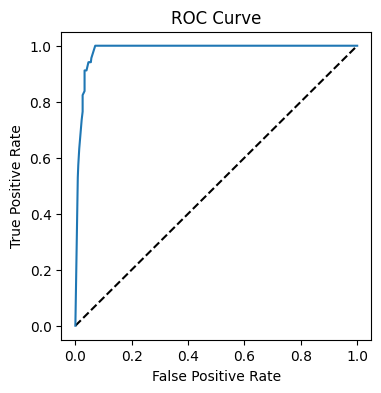

AUC: 0.9848013947847181
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 4 / max leaf node: None
        Features  Importances
9       month_no     0.398080
8      STORM_LEN     0.212712
0       USA_SSHS     0.126874
3    CD2LANDFALL     0.085478
2        CD2LAND     0.081781
5        INBOUND     0.054935
6         CD2OIL     0.016326
7        OIL_THT     0.013280
4       CD2METRO     0.010534
1  STORM_LOC_BIN     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



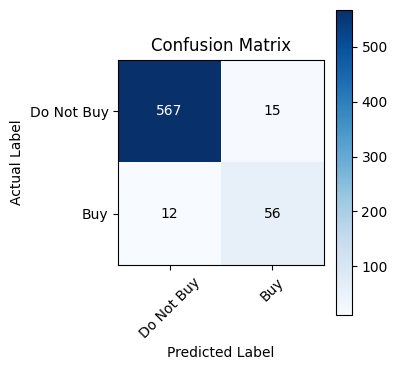

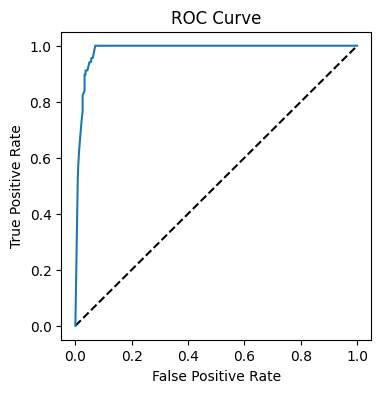

AUC: 0.9845360824742269
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 6 / max leaf node: None
        Features  Importances
9       month_no     0.400715
8      STORM_LEN     0.228512
0       USA_SSHS     0.146180
3    CD2LANDFALL     0.084466
2        CD2LAND     0.083557
5        INBOUND     0.030787
7        OIL_THT     0.013391
4       CD2METRO     0.010627
1  STORM_LOC_BIN     0.001766
6         CD2OIL     0.000000
Mean Squared Error:  0.04461538461538461
R-squared:  0.5237012330705478
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.78      0.79      0.79        68

    accuracy                           0.96       650
   macro avg       0.88      0.88      0.88       650
weighted avg       0.96      0.96      0.96       650



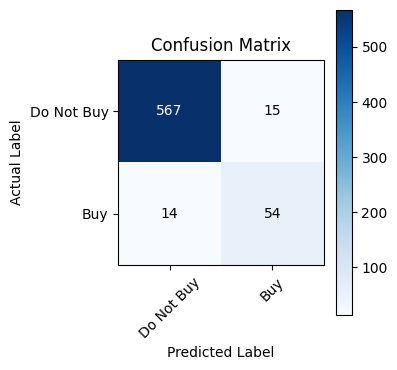

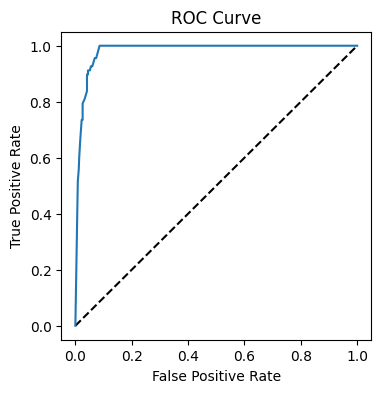

AUC: 0.9820851020820699
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 8 / max leaf node: None
        Features  Importances
9       month_no     0.419570
8      STORM_LEN     0.218952
0       USA_SSHS     0.139620
2        CD2LAND     0.086912
3    CD2LANDFALL     0.086786
5        INBOUND     0.032768
7        OIL_THT     0.015391
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04461538461538461
R-squared:  0.5237012330705478
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.78      0.79      0.79        68

    accuracy                           0.96       650
   macro avg       0.88      0.88      0.88       650
weighted avg       0.96      0.96      0.96       650



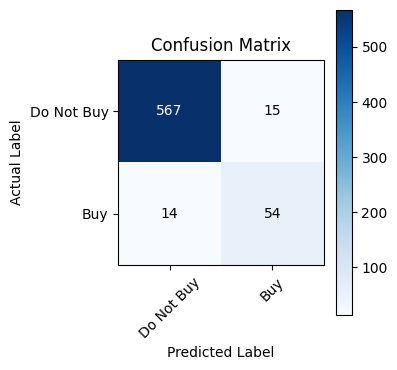

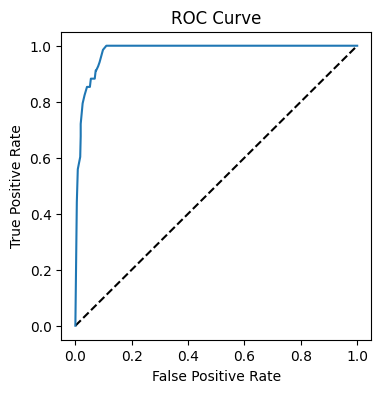

AUC: 0.9801521123913483
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 10 / max leaf node: None
        Features  Importances
9       month_no     0.417993
8      STORM_LEN     0.234186
0       USA_SSHS     0.133173
2        CD2LAND     0.092720
3    CD2LANDFALL     0.083161
5        INBOUND     0.019246
7        OIL_THT     0.015049
1  STORM_LOC_BIN     0.004472
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       582
           1       0.71      0.79      0.75        68

    accuracy                           0.94       650
   macro avg       0.84      0.88      0.86       650
weighted avg       0.95      0.94      0.95       650



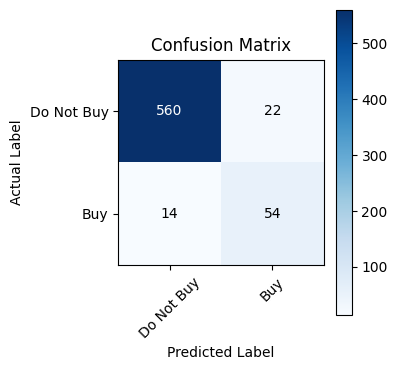

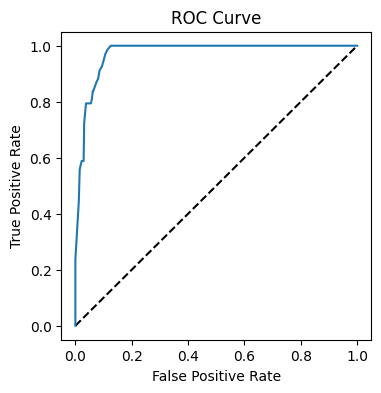

AUC: 0.9727107337780473
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 12 / max leaf node: None
        Features  Importances
9       month_no     0.419743
8      STORM_LEN     0.226237
0       USA_SSHS     0.138190
2        CD2LAND     0.102814
3    CD2LANDFALL     0.083707
7        OIL_THT     0.015148
5        INBOUND     0.014161
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       582
           1       0.71      0.79      0.75        68

    accuracy                           0.94       650
   macro avg       0.84      0.88      0.86       650
weighted avg       0.95      0.94      0.95       650



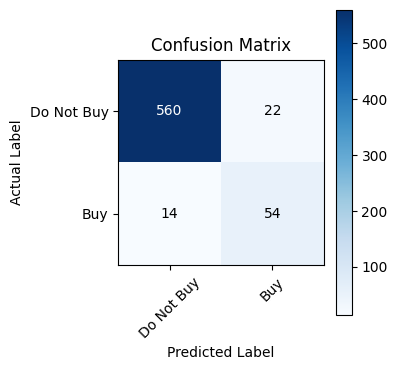

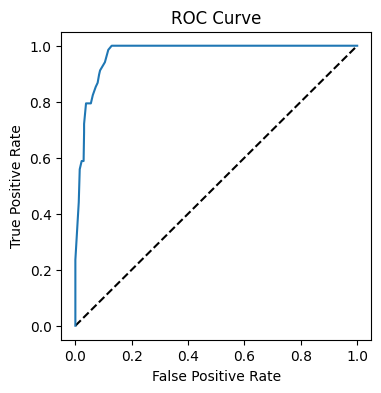

AUC: 0.9720664038811401
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 14 / max leaf node: None
        Features  Importances
9       month_no     0.407864
8      STORM_LEN     0.239066
0       USA_SSHS     0.139489
2        CD2LAND     0.096277
3    CD2LANDFALL     0.082199
5        INBOUND     0.019140
7        OIL_THT     0.015965
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.06615384615384616
R-squared:  0.293763897311502
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       582
           1       0.70      0.65      0.67        68

    accuracy                           0.93       650
   macro avg       0.83      0.81      0.82       650
weighted avg       0.93      0.93      0.93       650



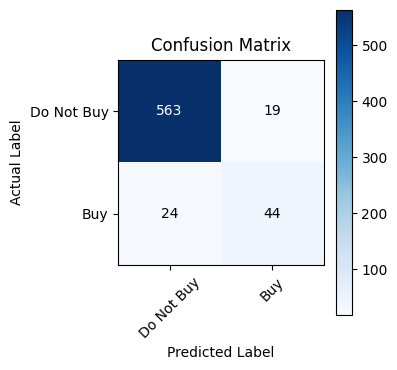

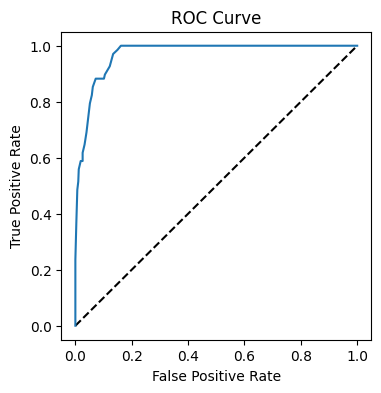

AUC: 0.9698428340408328
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 16 / max leaf node: None
        Features  Importances
9       month_no     0.443878
8      STORM_LEN     0.221397
0       USA_SSHS     0.105554
3    CD2LANDFALL     0.086532
2        CD2LAND     0.085350
5        INBOUND     0.041497
7        OIL_THT     0.015792
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05384615384615385
R-squared:  0.42515666060238533
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.69      0.73        68

    accuracy                           0.95       650
   macro avg       0.87      0.83      0.85       650
weighted avg       0.94      0.95      0.94       650



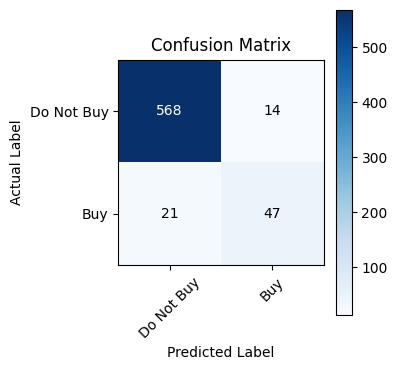

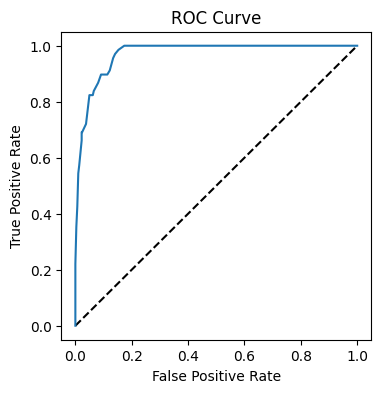

AUC: 0.9707903780068727
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 18 / max leaf node: None
        Features  Importances
9       month_no     0.459353
8      STORM_LEN     0.202822
0       USA_SSHS     0.114488
2        CD2LAND     0.089741
3    CD2LANDFALL     0.069933
5        INBOUND     0.047058
7        OIL_THT     0.016605
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05692307692307692
R-squared:  0.3923084697796645
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.65      0.70        68

    accuracy                           0.94       650
   macro avg       0.87      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



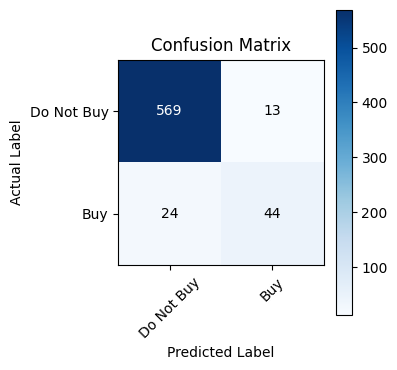

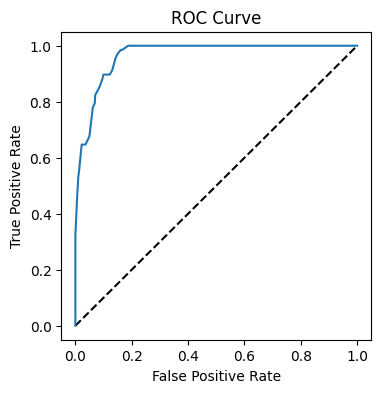

AUC: 0.9656862745098039
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 2
        Features  Importances
9       month_no          1.0
0       USA_SSHS          0.0
1  STORM_LOC_BIN          0.0
2        CD2LAND          0.0
4       CD2METRO          0.0
3    CD2LANDFALL          0.0
5        INBOUND          0.0
6         CD2OIL          0.0
7        OIL_THT          0.0
8      STORM_LEN          0.0
Mean Squared Error:  0.09384615384615384
R-squared:  -0.0018698200929856412
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       582
           1       0.59      0.35      0.44        68

    accuracy                           0.91       650
   macro avg       0.76      0.66      0.69       650
weighted avg       0.89      0.91      0.90       650



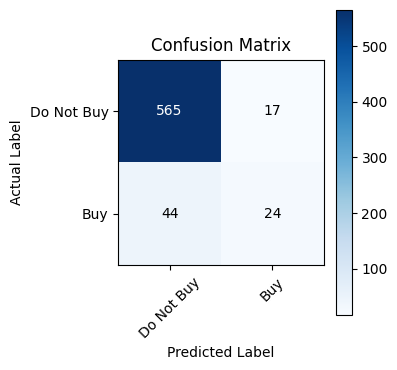

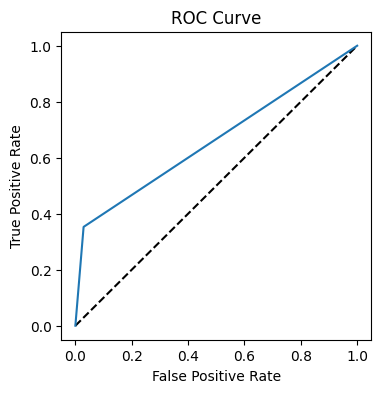

AUC: 0.6618657772387305
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 4
        Features  Importances
9       month_no     0.875688
2        CD2LAND     0.124312
1  STORM_LOC_BIN     0.000000
0       USA_SSHS     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
7        OIL_THT     0.000000
8      STORM_LEN     0.000000
Mean Squared Error:  0.09384615384615384
R-squared:  -0.0018698200929856412
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       582
           1       0.59      0.35      0.44        68

    accuracy                           0.91       650
   macro avg       0.76      0.66      0.69       650
weighted avg       0.89      0.91      0.90       650



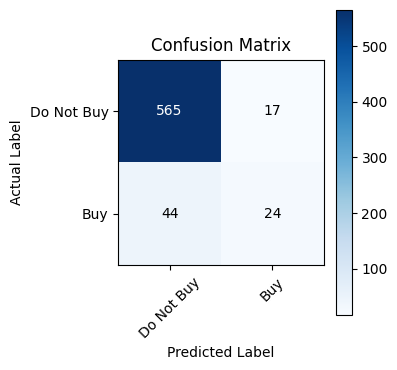

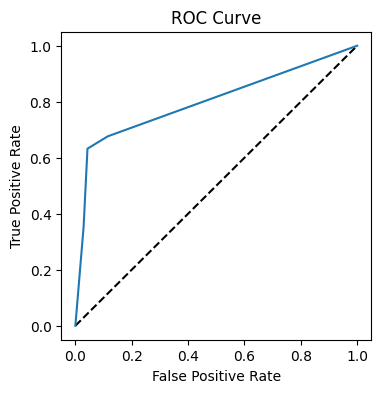

AUC: 0.8008894279361229
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 6
        Features  Importances
9       month_no     0.739819
2        CD2LAND     0.105024
8      STORM_LEN     0.089048
0       USA_SSHS     0.066109
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.07384615384615385
R-squared:  0.21164342025469995
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       582
           1       0.66      0.60      0.63        68

    accuracy                           0.93       650
   macro avg       0.81      0.78      0.79       650
weighted avg       0.92      0.93      0.92       650



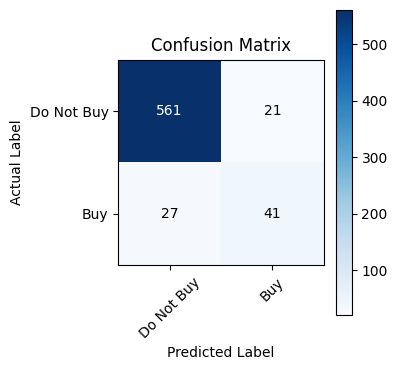

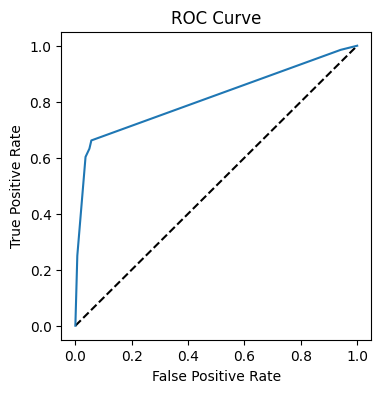

AUC: 0.8129674550232464
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 8
        Features  Importances
9       month_no     0.670825
2        CD2LAND     0.147956
8      STORM_LEN     0.121276
0       USA_SSHS     0.059944
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.07384615384615385
R-squared:  0.21164342025469995
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       582
           1       0.66      0.60      0.63        68

    accuracy                           0.93       650
   macro avg       0.81      0.78      0.79       650
weighted avg       0.92      0.93      0.92       650



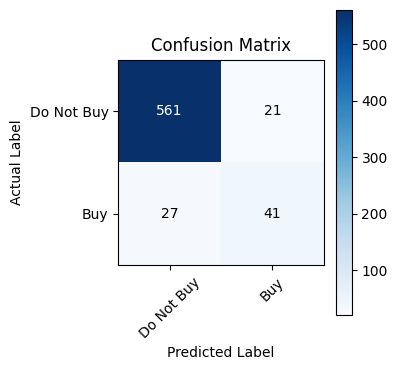

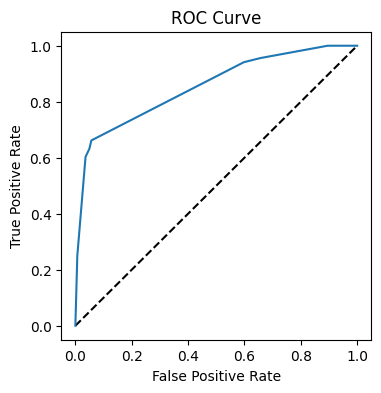

AUC: 0.8538255508388923
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 10
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



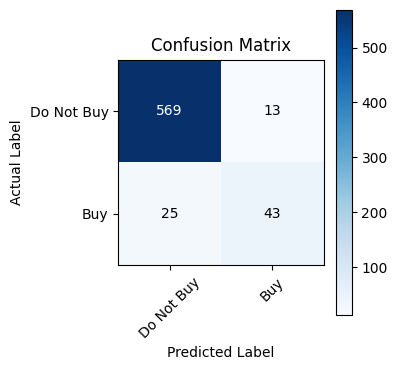

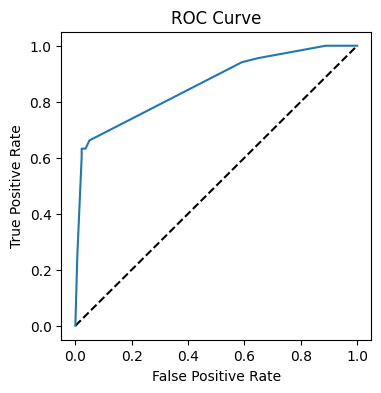

AUC: 0.8594855467960381
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 12
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



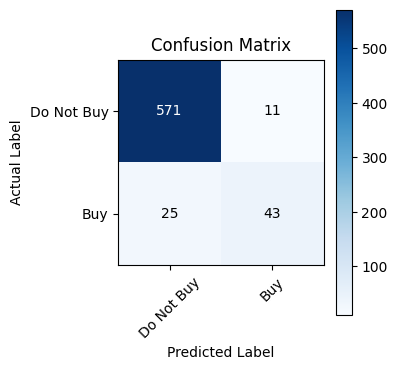

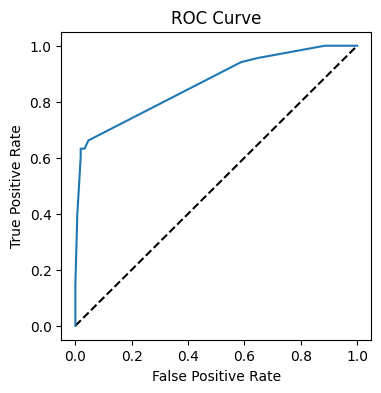

AUC: 0.8633515261774813
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 14
        Features  Importances
9       month_no     0.547518
8      STORM_LEN     0.195236
2        CD2LAND     0.120759
0       USA_SSHS     0.081421
3    CD2LANDFALL     0.032721
7        OIL_THT     0.022344
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       582
           1       0.83      0.56      0.67        68

    accuracy                           0.94       650
   macro avg       0.89      0.77      0.82       650
weighted avg       0.94      0.94      0.94       650



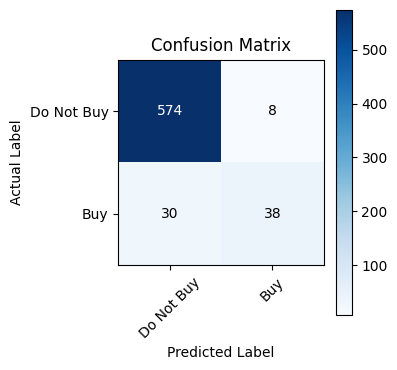

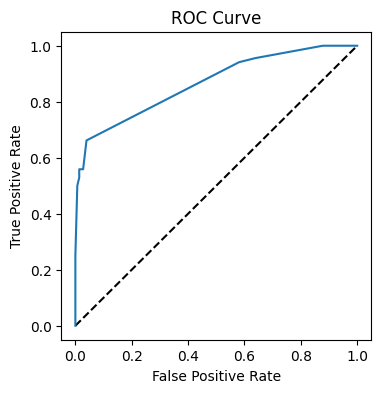

AUC: 0.8658909440064686
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 16
        Features  Importances
9       month_no     0.520492
8      STORM_LEN     0.216559
2        CD2LAND     0.114799
0       USA_SSHS     0.095802
3    CD2LANDFALL     0.031106
7        OIL_THT     0.021241
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       582
           1       0.83      0.56      0.67        68

    accuracy                           0.94       650
   macro avg       0.89      0.77      0.82       650
weighted avg       0.94      0.94      0.94       650



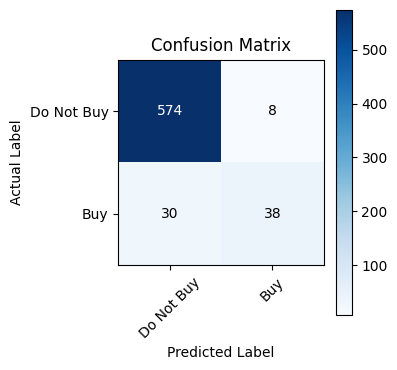

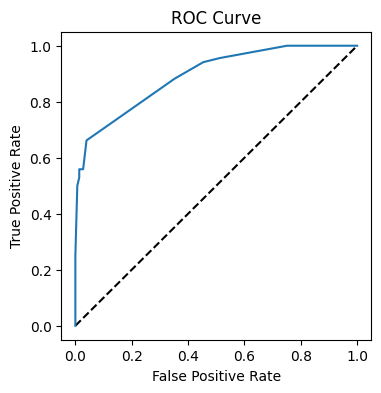

AUC: 0.8931170406306852
Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 18
        Features  Importances
9       month_no     0.501602
8      STORM_LEN     0.226078
2        CD2LAND     0.110632
0       USA_SSHS     0.092325
3    CD2LANDFALL     0.048891
7        OIL_THT     0.020470
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.06
R-squared:  0.35946027895694366
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.80      0.57      0.67        68

    accuracy                           0.94       650
   macro avg       0.87      0.78      0.82       650
weighted avg       0.94      0.94      0.94       650



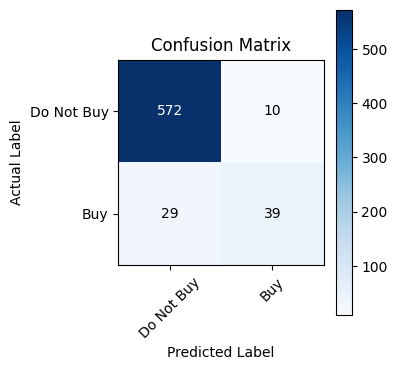

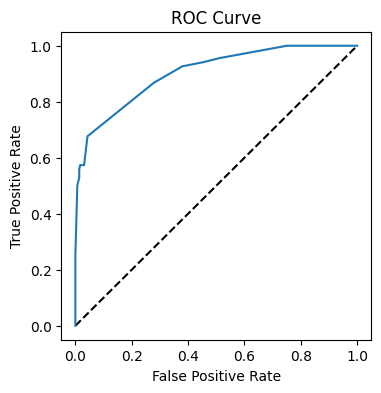

AUC: 0.9032494441075399
       data_model  max_lvl  leaf  leafnode       mse        r2       acc  \
0   model_all_avg      2.0     1       NaN  0.081538  0.129523  0.918462   
1   model_all_avg      4.0     1       NaN  0.058462  0.375884  0.941538   
2   model_all_avg      6.0     1       NaN  0.049231  0.474429  0.950769   
3   model_all_avg      8.0     1       NaN  0.046154  0.507277  0.953846   
4   model_all_avg     10.0     1       NaN  0.044615  0.523701  0.955385   
5   model_all_avg     12.0     1       NaN  0.043077  0.540125  0.956923   
6   model_all_avg     14.0     1       NaN  0.041538  0.556549  0.958462   
7   model_all_avg     16.0     1       NaN  0.041538  0.556549  0.958462   
8   model_all_avg     18.0     1       NaN  0.041538  0.556549  0.958462   
9   model_all_avg      NaN     2       NaN  0.041538  0.556549  0.958462   
10  model_all_avg      NaN     4       NaN  0.041538  0.556549  0.958462   
11  model_all_avg      NaN     6       NaN  0.044615  0.523701  

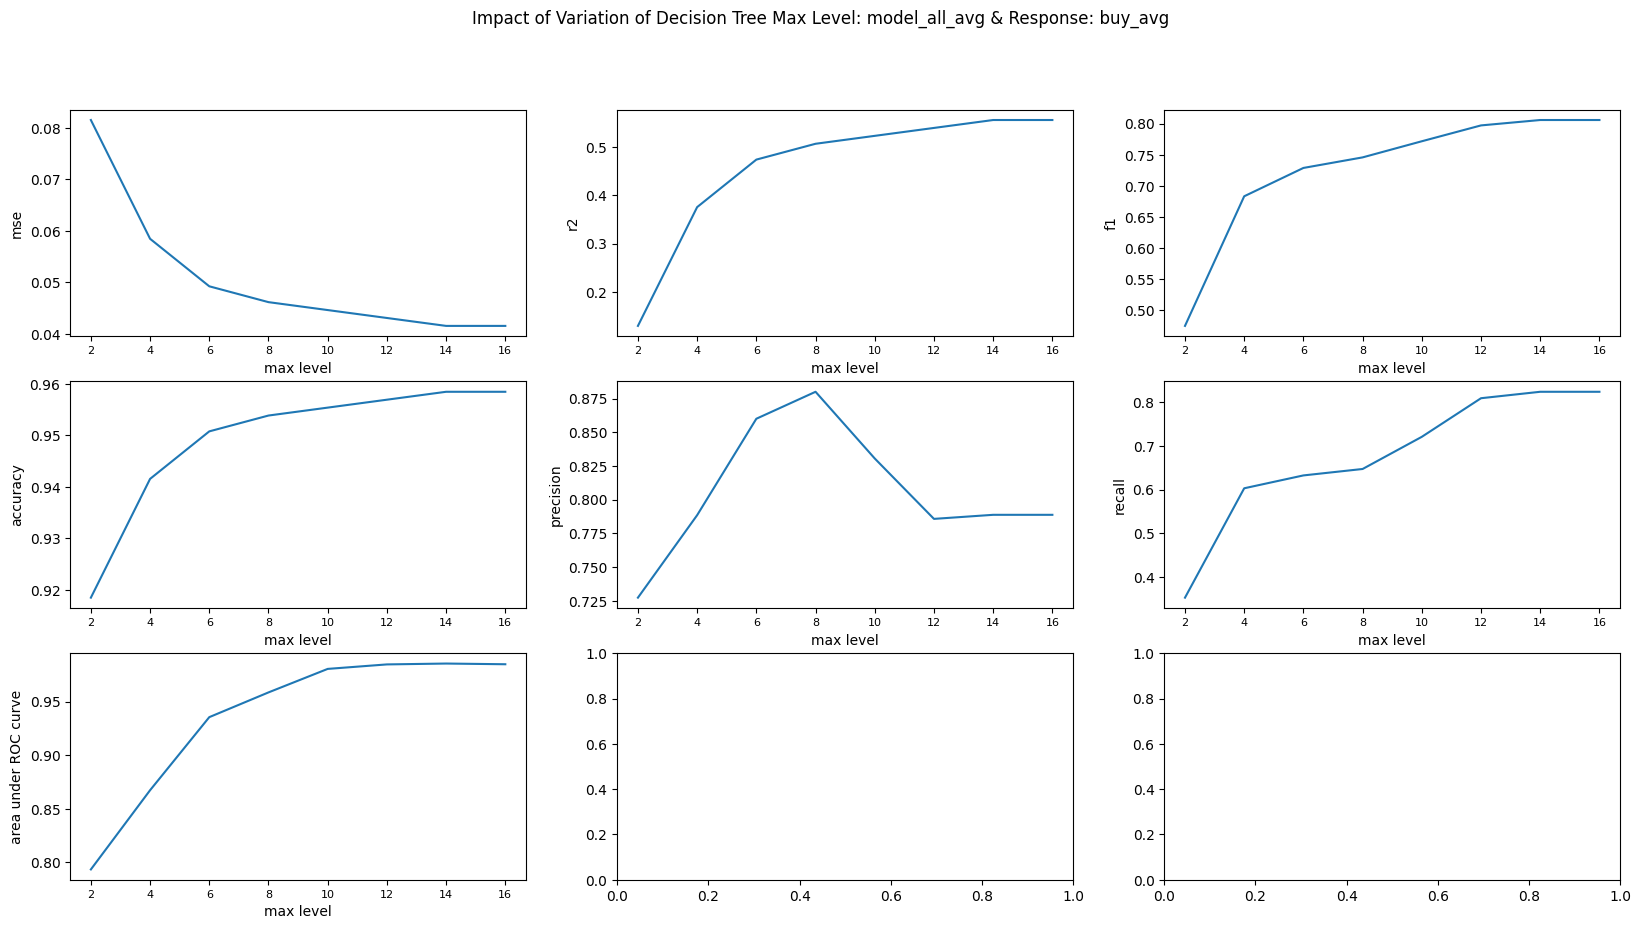

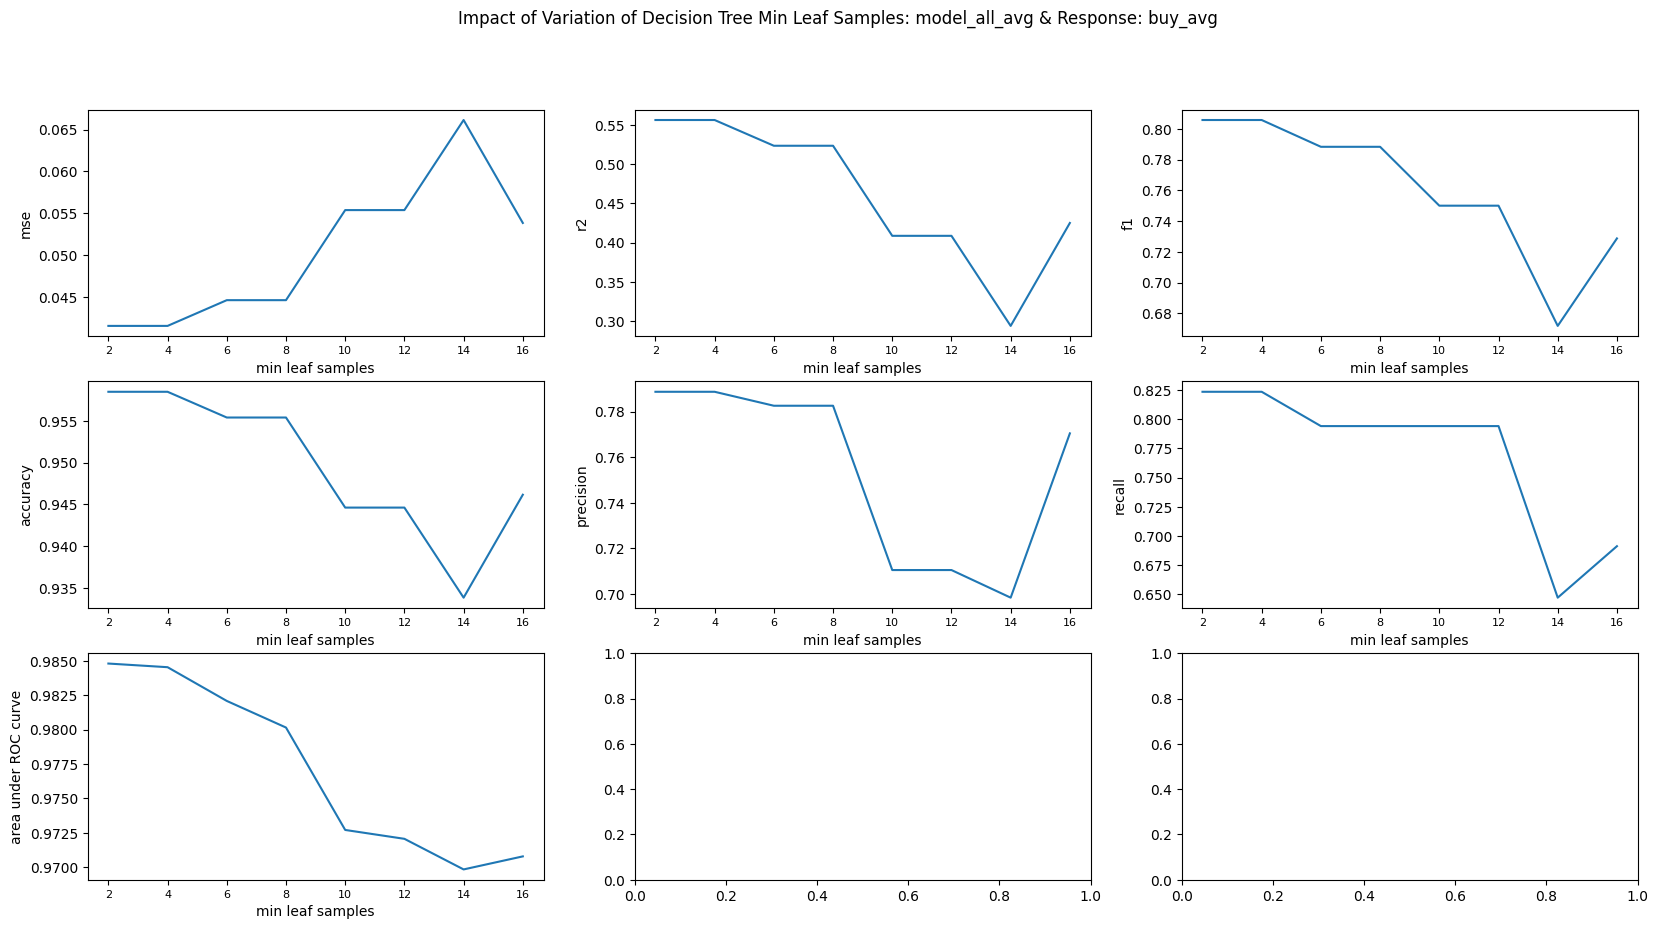

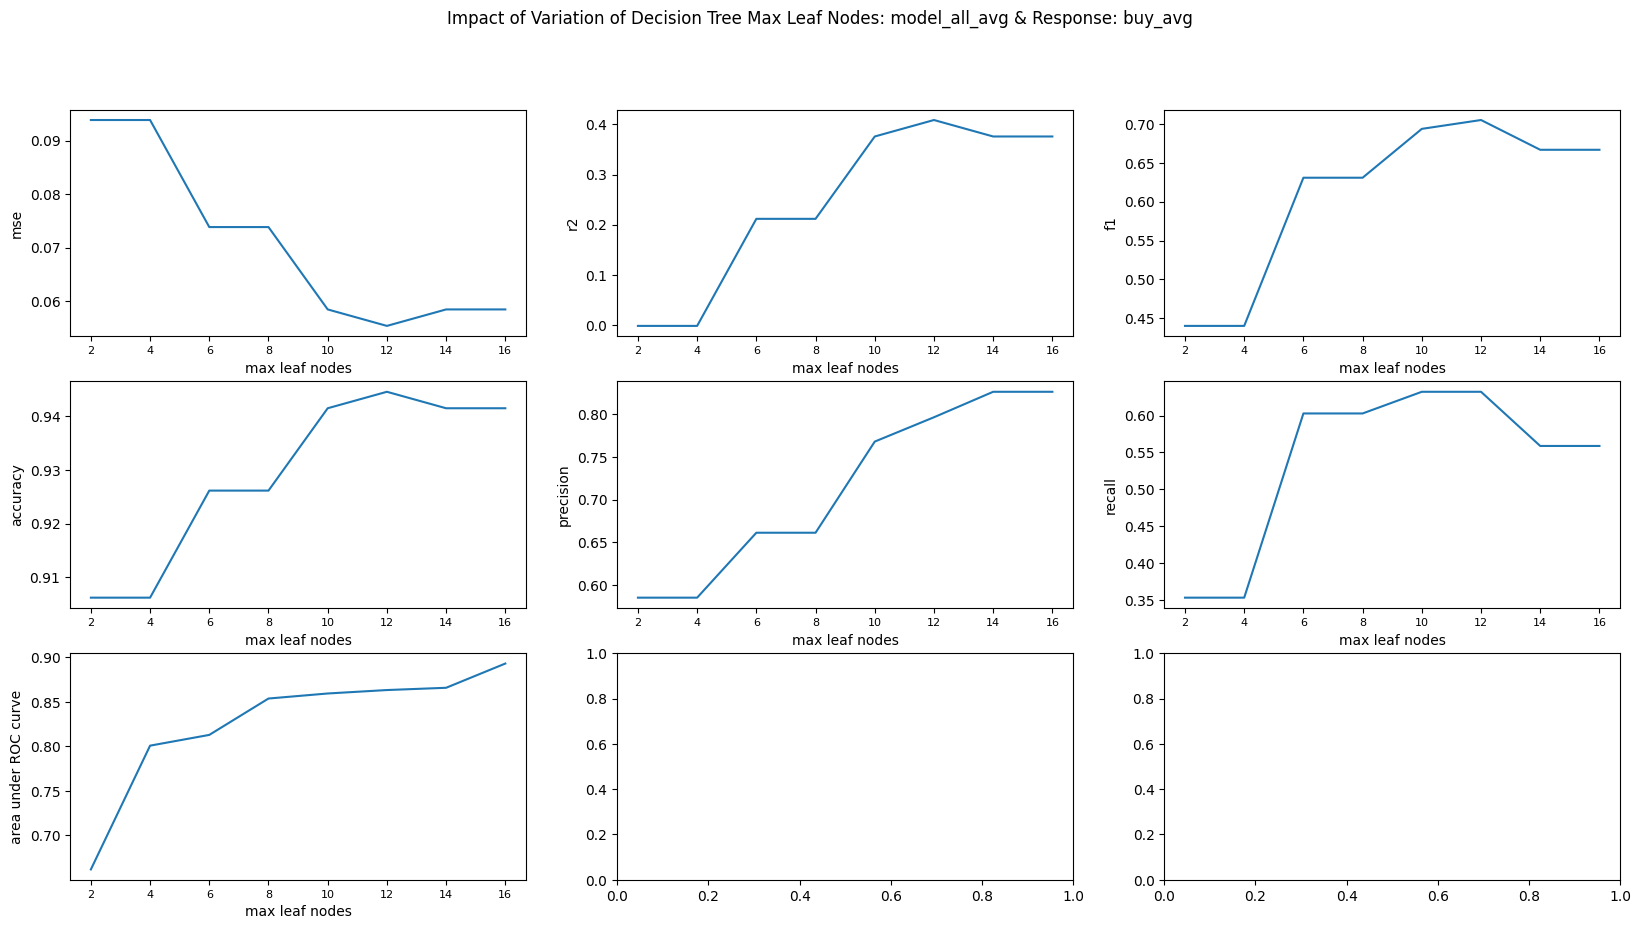

In [13]:
model_list = [model_all_avg]
model_names = ['model_all_avg']

model_dec_tree_hyp_par_eval(model_list, model_names,class_list, 'buy_avg', None, 1, None,0)

Based on the output plots, model evaluation should focus on the following ranges:
max tree level: 4-6
min leaf samples: 3-4
max leaf nodes: 10-12

In [14]:
# set parameters for further evaluation
max_lvl_set = [4,5,6]
min_leaf_set = [3,4]
max_node_set = [10,11,12]

Model: model_1_4_3_10 (1) / Response: buy_avg
        Features  Importances
9       month_no     0.632228
8      STORM_LEN     0.146032
2        CD2LAND     0.139443
0       USA_SSHS     0.056495
7        OIL_THT     0.025801
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



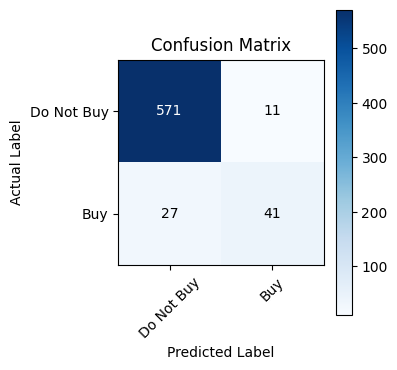

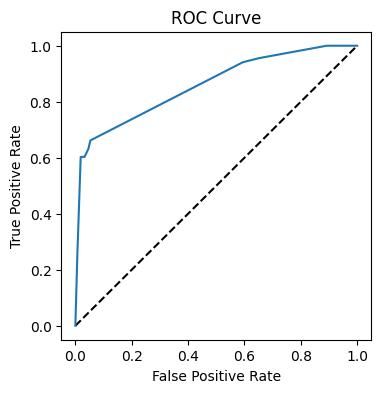

AUC: 0.858222154841318
Model: model_2_4_3_11 (2) / Response: buy_avg
        Features  Importances
9       month_no     0.599414
8      STORM_LEN     0.190356
2        CD2LAND     0.132205
0       USA_SSHS     0.053563
7        OIL_THT     0.024462
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



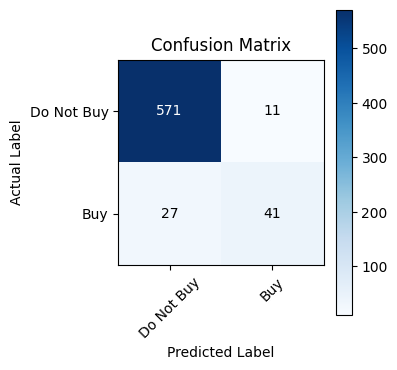

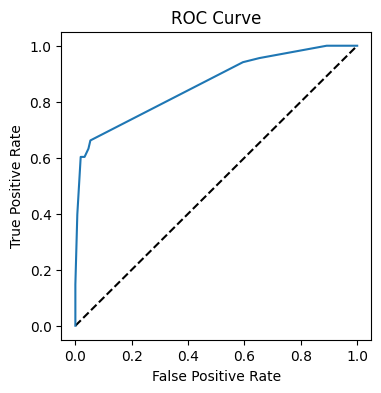

AUC: 0.8601172427733981
Model: model_3_4_3_12 (3) / Response: buy_avg
        Features  Importances
9       month_no     0.587999
8      STORM_LEN     0.186731
2        CD2LAND     0.129688
0       USA_SSHS     0.052543
7        OIL_THT     0.023996
4       CD2METRO     0.019043
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



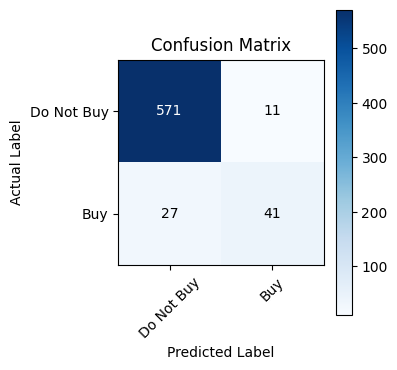

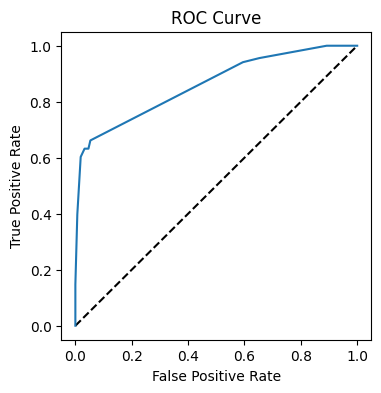

AUC: 0.8605215281989085
Model: model_4_4_4_10 (4) / Response: buy_avg
        Features  Importances
9       month_no     0.632228
8      STORM_LEN     0.146032
2        CD2LAND     0.139443
0       USA_SSHS     0.056495
7        OIL_THT     0.025801
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



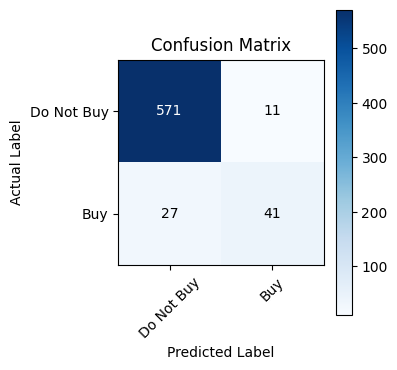

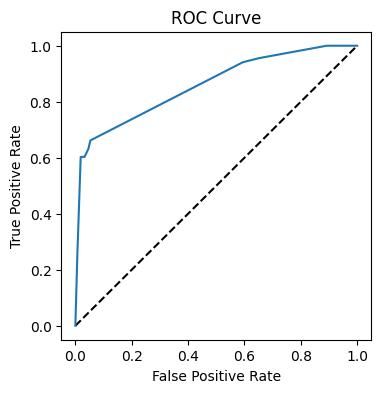

AUC: 0.858222154841318
Model: model_5_4_4_11 (5) / Response: buy_avg
        Features  Importances
9       month_no     0.599414
8      STORM_LEN     0.190356
2        CD2LAND     0.132205
0       USA_SSHS     0.053563
7        OIL_THT     0.024462
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



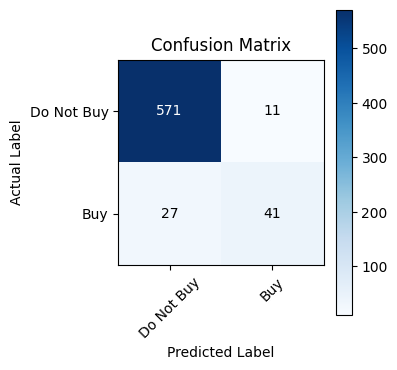

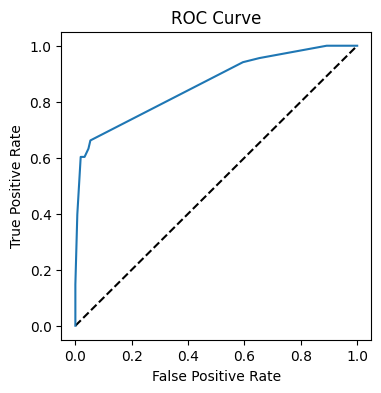

AUC: 0.8601172427733981
Model: model_6_4_4_12 (6) / Response: buy_avg
        Features  Importances
9       month_no     0.587999
8      STORM_LEN     0.186731
2        CD2LAND     0.129688
0       USA_SSHS     0.052543
7        OIL_THT     0.023996
4       CD2METRO     0.019043
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.79      0.60      0.68        68

    accuracy                           0.94       650
   macro avg       0.87      0.79      0.83       650
weighted avg       0.94      0.94      0.94       650



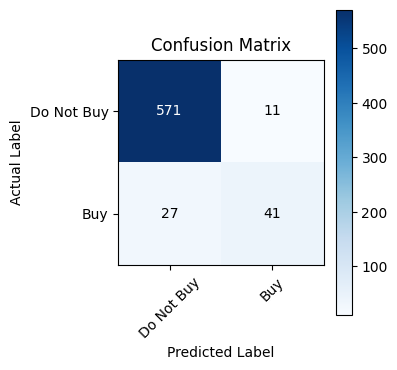

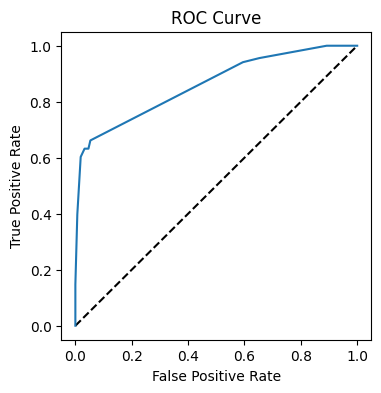

AUC: 0.8605215281989085
Model: model_7_5_3_10 (7) / Response: buy_avg
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



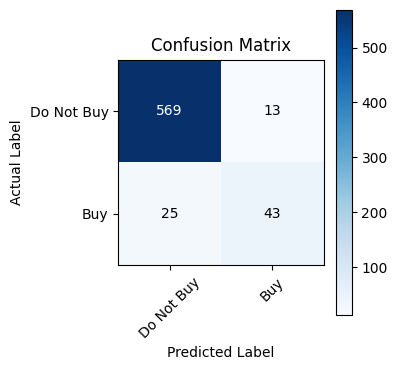

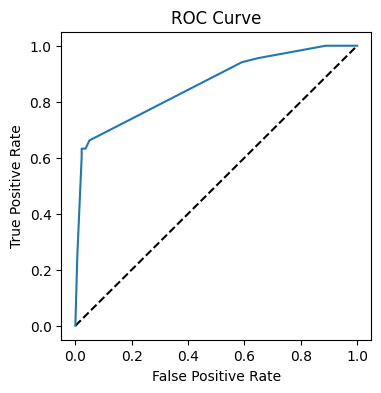

AUC: 0.8594855467960381
Model: model_8_5_3_11 (8) / Response: buy_avg
        Features  Importances
9       month_no     0.609363
8      STORM_LEN     0.140751
2        CD2LAND     0.134400
0       USA_SSHS     0.090618
7        OIL_THT     0.024868
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



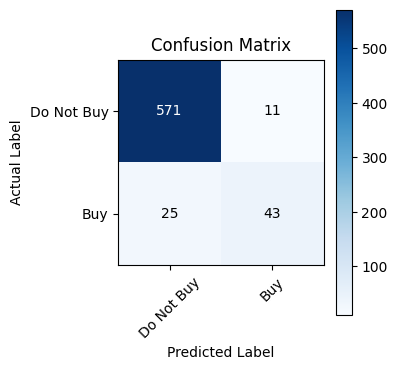

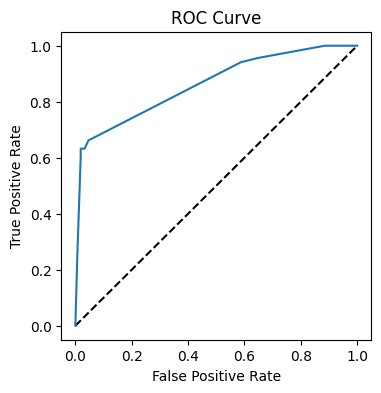

AUC: 0.8614564382454013
Model: model_9_5_3_12 (9) / Response: buy_avg
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



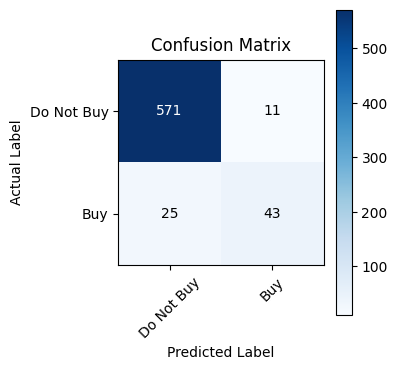

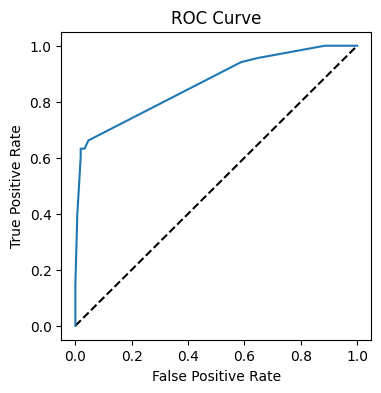

AUC: 0.8633515261774813
Model: model_10_5_4_10 (10) / Response: buy_avg
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



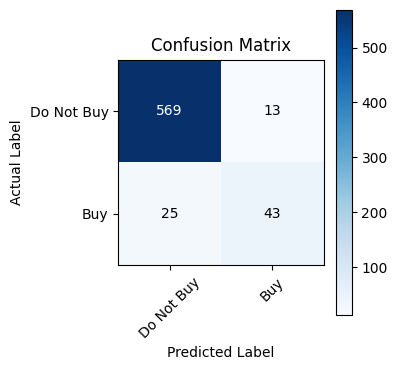

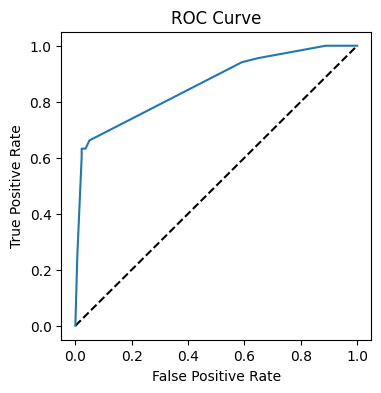

AUC: 0.8594855467960381
Model: model_11_5_4_11 (11) / Response: buy_avg
        Features  Importances
9       month_no     0.609363
8      STORM_LEN     0.140751
2        CD2LAND     0.134400
0       USA_SSHS     0.090618
7        OIL_THT     0.024868
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



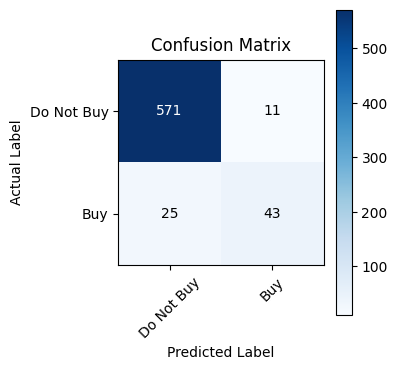

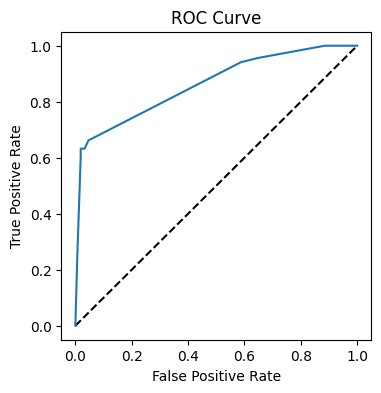

AUC: 0.8614564382454013
Model: model_12_5_4_12 (12) / Response: buy_avg
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



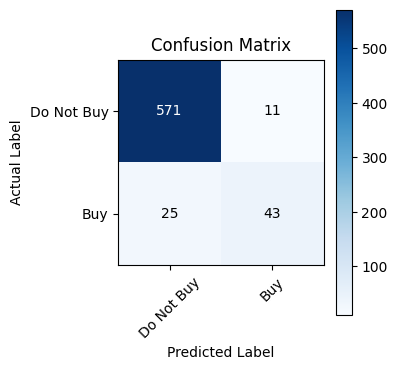

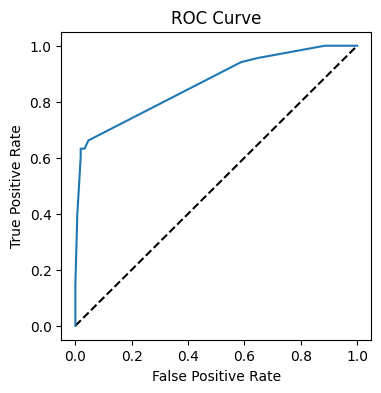

AUC: 0.8633515261774813
Model: model_13_6_3_10 (13) / Response: buy_avg
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



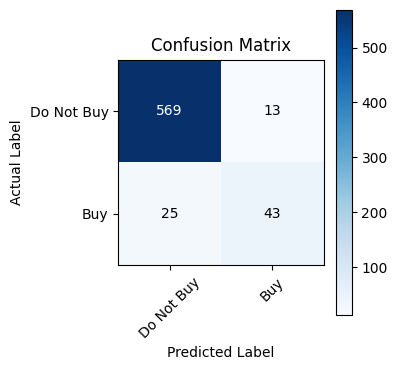

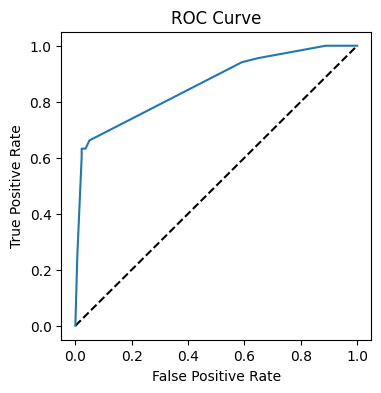

AUC: 0.8594855467960381
Model: model_14_6_3_11 (14) / Response: buy_avg
        Features  Importances
9       month_no     0.609363
8      STORM_LEN     0.140751
2        CD2LAND     0.134400
0       USA_SSHS     0.090618
7        OIL_THT     0.024868
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



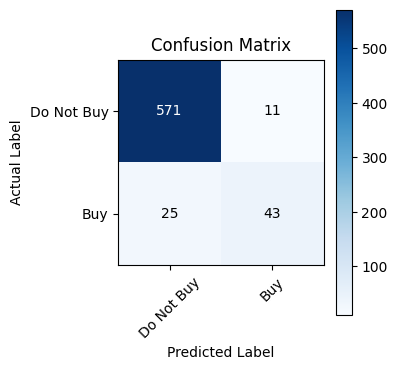

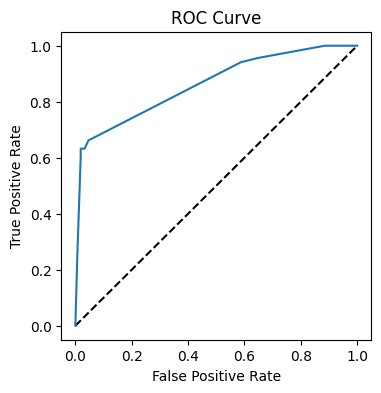

AUC: 0.8614564382454013
Model: model_15_6_3_12 (15) / Response: buy_avg
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



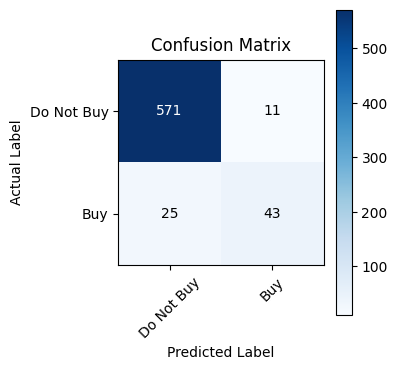

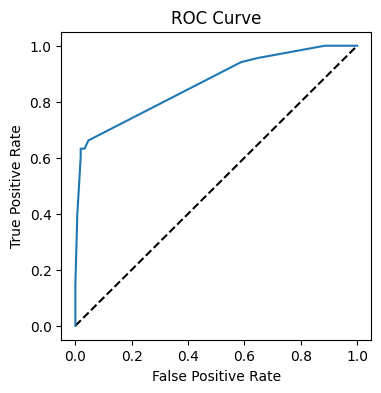

AUC: 0.8633515261774813
Model: model_16_6_4_10 (16) / Response: buy_avg
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



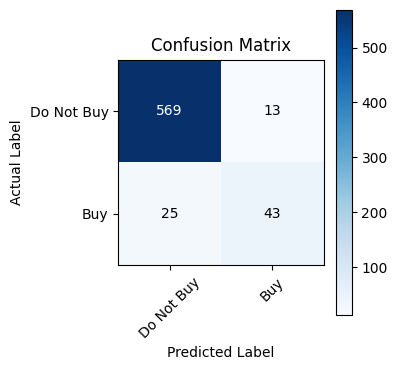

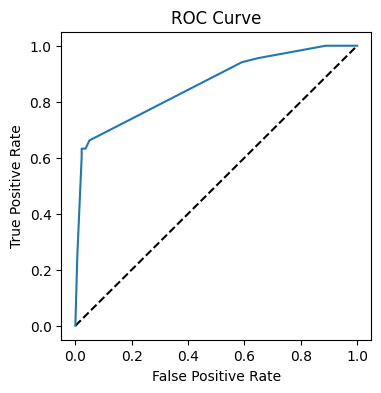

AUC: 0.8594855467960381
Model: model_17_6_4_11 (17) / Response: buy_avg
        Features  Importances
9       month_no     0.609363
8      STORM_LEN     0.140751
2        CD2LAND     0.134400
0       USA_SSHS     0.090618
7        OIL_THT     0.024868
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



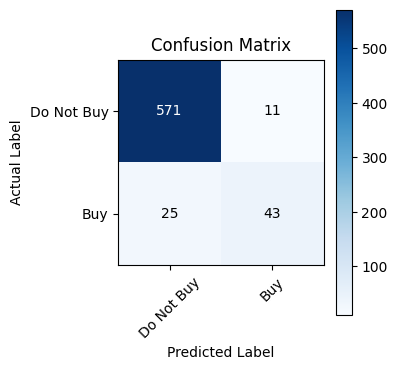

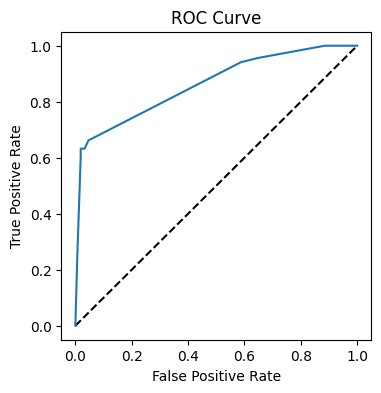

AUC: 0.8614564382454013
Model: model_18_6_4_12 (18) / Response: buy_avg
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



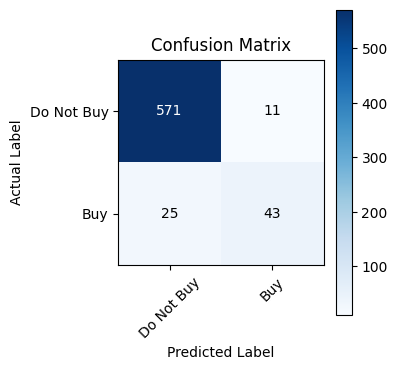

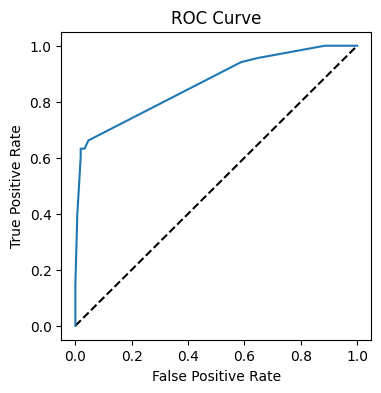

AUC: 0.8633515261774813
         data_model       mse        r2       acc      prec       rec  \
0    model_1_4_3_10  0.058462  0.375884  0.941538  0.788462  0.602941   
1    model_2_4_3_11  0.058462  0.375884  0.941538  0.788462  0.602941   
2    model_3_4_3_12  0.058462  0.375884  0.941538  0.788462  0.602941   
3    model_4_4_4_10  0.058462  0.375884  0.941538  0.788462  0.602941   
4    model_5_4_4_11  0.058462  0.375884  0.941538  0.788462  0.602941   
5    model_6_4_4_12  0.058462  0.375884  0.941538  0.788462  0.602941   
6    model_7_5_3_10  0.058462  0.375884  0.941538  0.767857  0.632353   
7    model_8_5_3_11  0.055385  0.408733  0.944615  0.796296  0.632353   
8    model_9_5_3_12  0.055385  0.408733  0.944615  0.796296  0.632353   
9   model_10_5_4_10  0.058462  0.375884  0.941538  0.767857  0.632353   
10  model_11_5_4_11  0.055385  0.408733  0.944615  0.796296  0.632353   
11  model_12_5_4_12  0.055385  0.408733  0.944615  0.796296  0.632353   
12  model_13_6_3_10  0.0584

In [15]:
param_results = dt_param(model_all_avg, 'buy_avg', max_lvl_set, min_leaf_set, max_node_set)

Based on the generated table, model 9 is selected.

    Features  Importances
4   month_no     0.578822
3  STORM_LEN     0.183816
1    CD2LAND     0.127664
0   USA_SSHS     0.086076
2    OIL_THT     0.023622
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



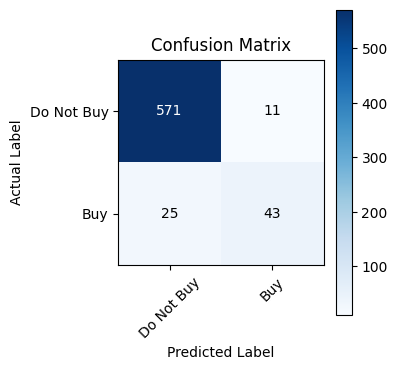

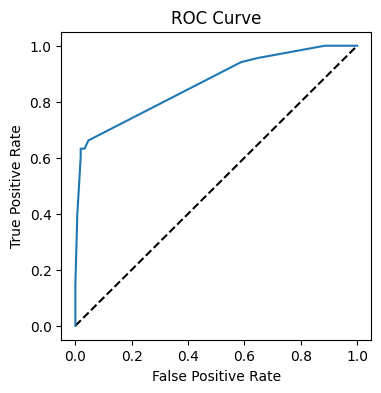

AUC: 0.8633515261774813


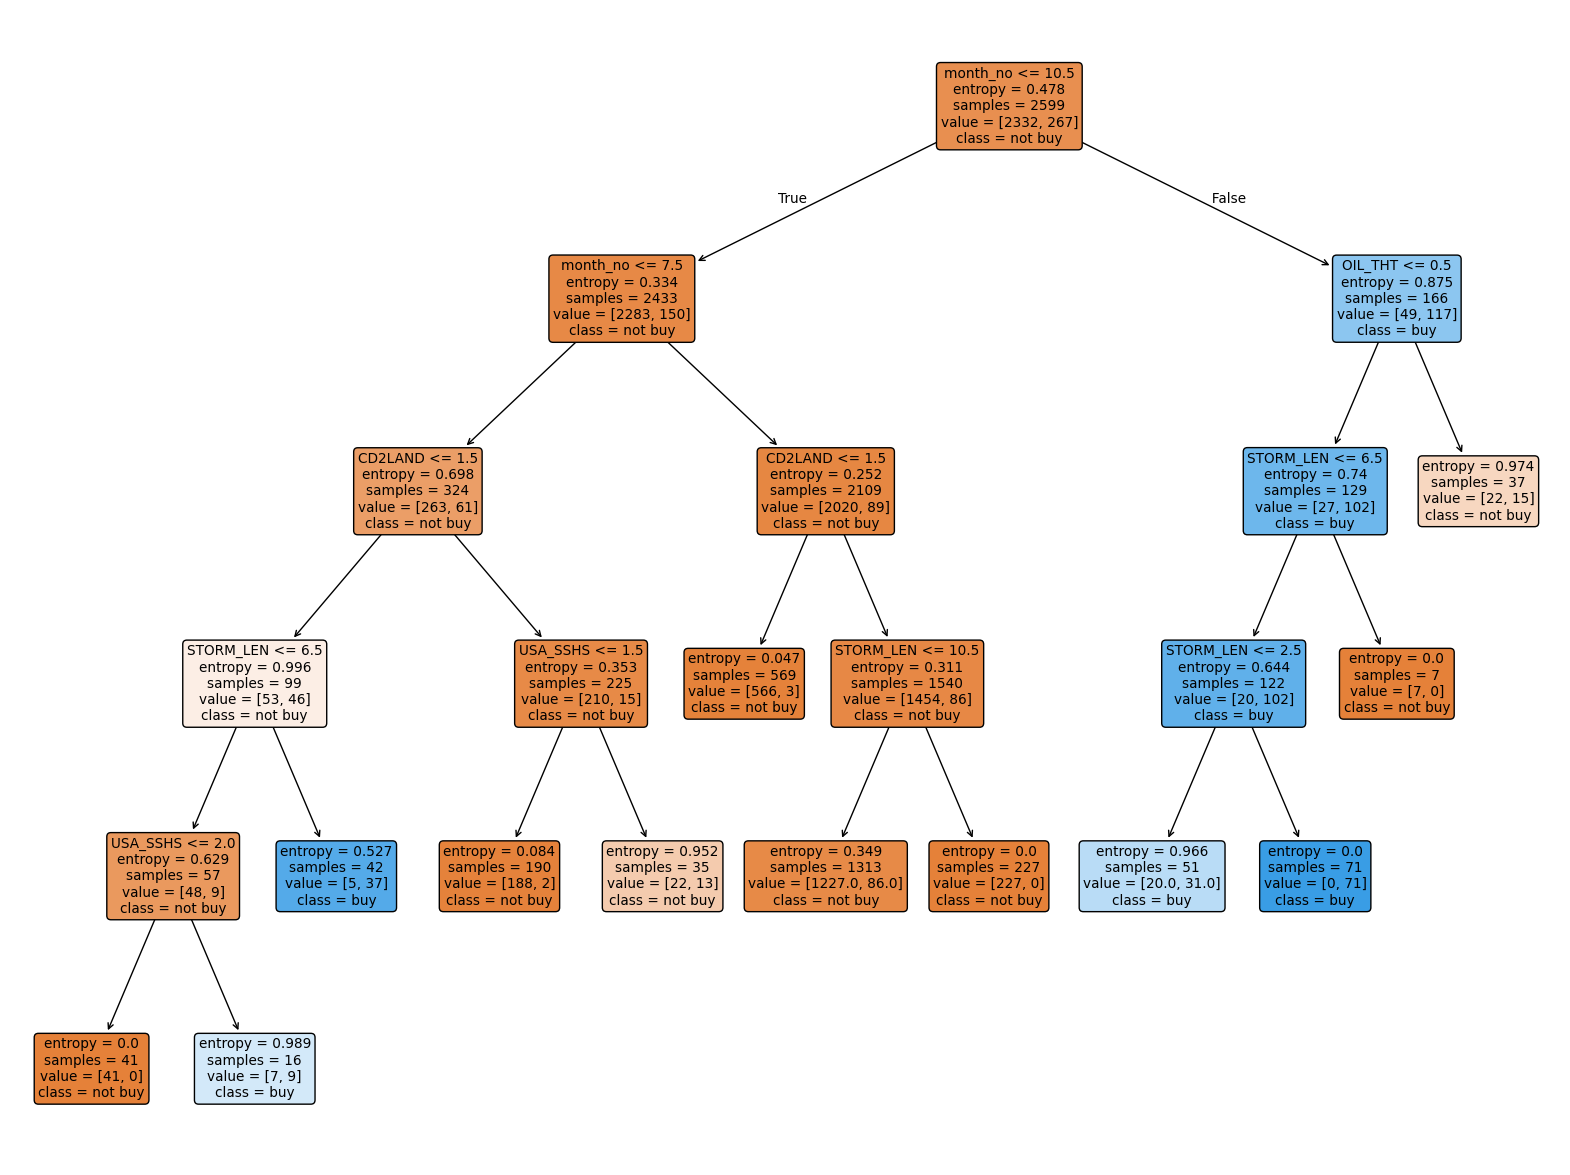

In [16]:
model_sel_avg = model_data[['USA_SSHS', 'CD2LAND', 'OIL_THT', 'STORM_LEN', 'month_no', 'buy_avg']]

dec_tree_std(model_sel_avg,'buy_avg',class_list,0.2, 5, 3, 12)

In [17]:
# Investigate what happens if try to use a balanced model

In [18]:
model = model_all_avg
y_param = 'buy_avg'
max_lvls = None
min_leaf_samp = 1
max_leaf_nod = None


        Features   Importances
9       month_no  3.617702e-01
8      STORM_LEN  2.807639e-01
0       USA_SSHS  1.669457e-01
2        CD2LAND  9.728107e-02
3    CD2LANDFALL  5.778611e-02
5        INBOUND  2.636195e-02
6         CD2OIL  8.439062e-03
1  STORM_LOC_BIN  6.520042e-04
7        OIL_THT  3.678023e-17
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.06307692307692307
R-squared:  0.3266120881342228
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       582
           1       0.62      1.00      0.77        68

    accuracy                           0.94       650
   macro avg       0.81      0.96      0.87       650
weighted avg       0.96      0.94      0.94       650



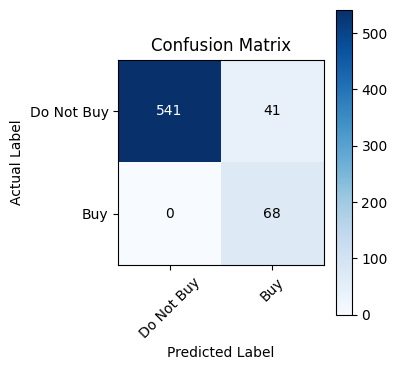

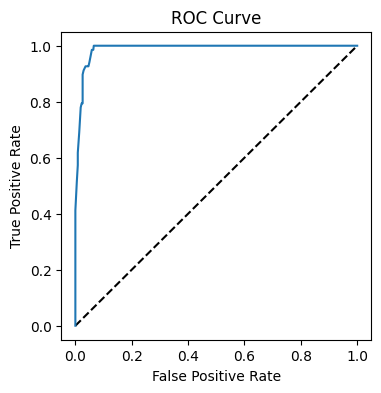

AUC: 0.9888063472811806


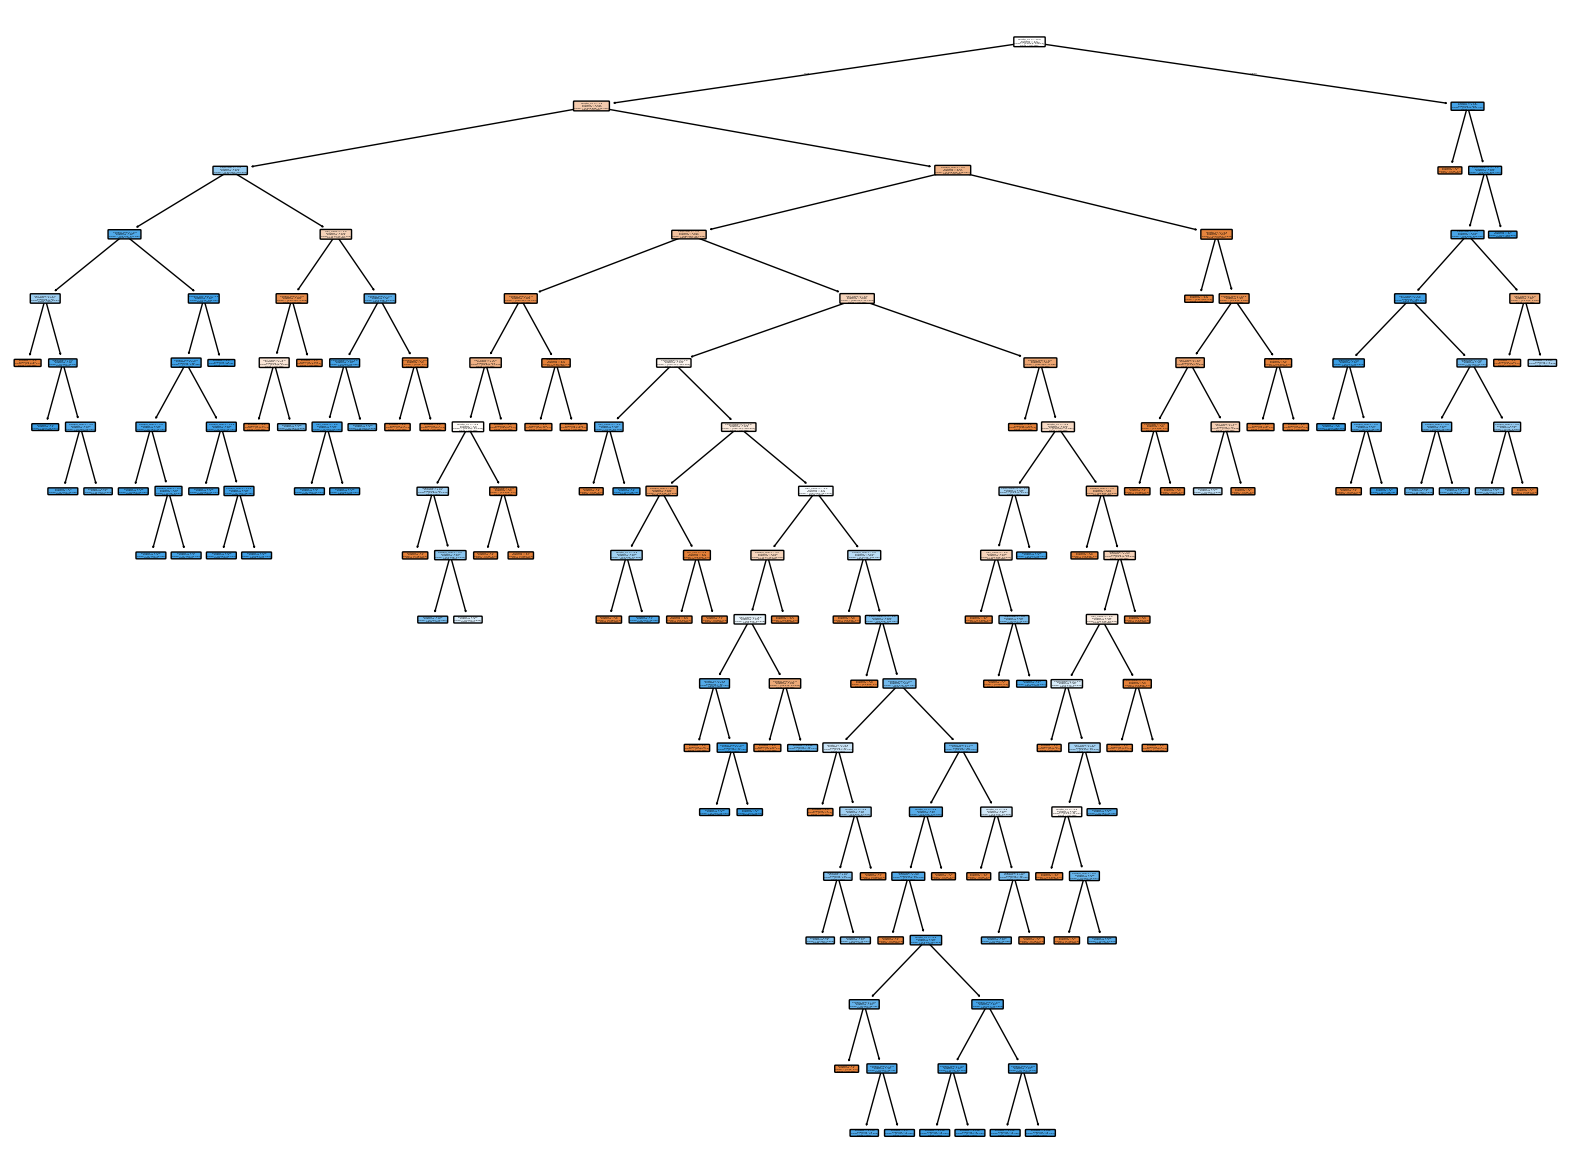

In [19]:
dec_tree_bal(model, y_param, class_list, 0.2, max_lvls, min_leaf_samp, max_leaf_nod)

#X_train_bal, X_test_bal, y_train_bal, y_test_bal,X_train, X_test, y_train, y_test, features_list = model_setup_bal(model,y_param,testsplit = 0.2)

#mod_dtb, y_pred, feat_list, feat_imp = model_dec_tree_bal(X_train_bal, X_test, y_train_bal, y_test, y_param, features_list, max_lvls, min_leaf_samp, max_leaf_nod)

#mse, r2, acc_sc, prec_sc, rec_sc, f1_sc, auc_sc = model_stats_analysis(y_test,y_pred,X_test,mod_dtb)



Balanced Model: model_all_avg (1) / Response: buy_avg
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 2 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.971995
6         CD2OIL     0.028005
1  STORM_LOC_BIN     0.000000
0       USA_SSHS     0.000000
2        CD2LAND     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
8      STORM_LEN     0.000000
Mean Squared Error:  0.13384615384615384
R-squared:  -0.4288963007883564
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       582
           1       0.41      0.68      0.51        68

    accuracy                           0.87       650
   macro avg       0.69      0.78      0.72       650
weighted avg       0.90      0.87      0.88       650



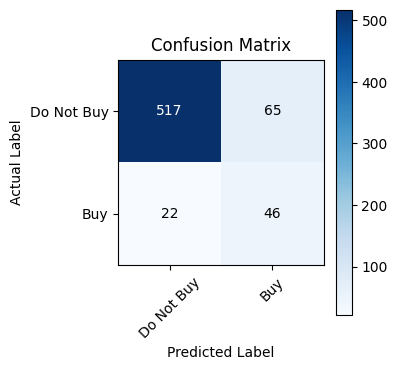

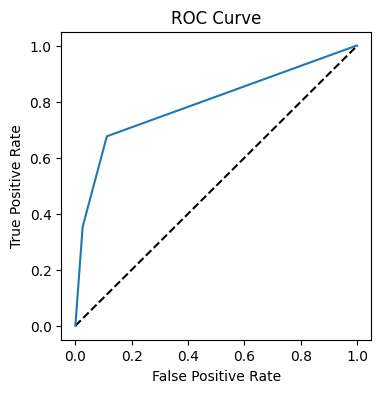

AUC: 0.7939407721851628
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 4 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.586011
2        CD2LAND     0.191626
8      STORM_LEN     0.115023
0       USA_SSHS     0.076709
6         CD2OIL     0.016623
3    CD2LANDFALL     0.014007
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
7        OIL_THT     0.000000
Mean Squared Error:  0.06769230769230769
R-squared:  0.2773398019001416
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       582
           1       0.68      0.66      0.67        68

    accuracy                           0.93       650
   macro avg       0.82      0.81      0.82       650
weighted avg       0.93      0.93      0.93       650



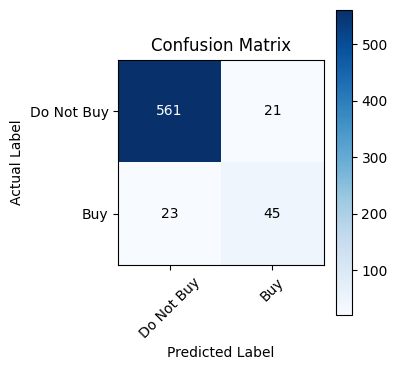

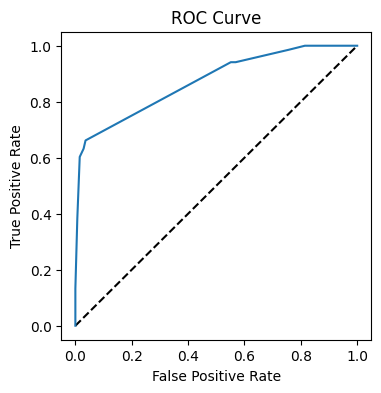

AUC: 0.8721952698605215
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 6 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.442046
8      STORM_LEN     0.204507
0       USA_SSHS     0.156723
2        CD2LAND     0.112335
3    CD2LANDFALL     0.060648
6         CD2OIL     0.012540
5        INBOUND     0.011202
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
Mean Squared Error:  0.06307692307692307
R-squared:  0.3266120881342228
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       582
           1       0.70      0.69      0.70        68

    accuracy                           0.94       650
   macro avg       0.83      0.83      0.83       650
weighted avg       0.94      0.94      0.94       650



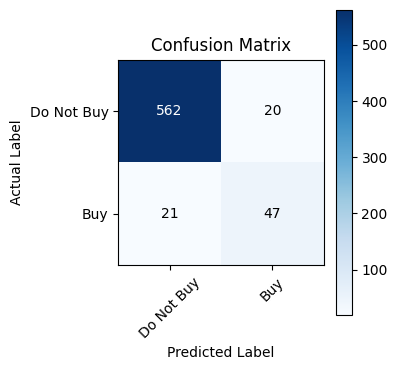

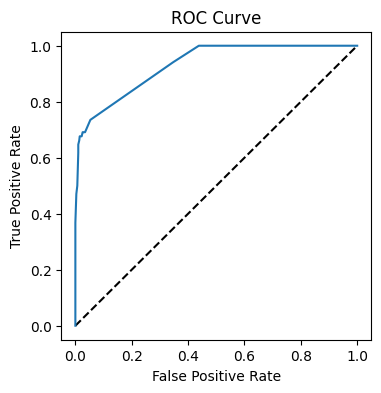

AUC: 0.9313725490196079
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 8 / min leaf: 1 / max leaf node: None
        Features  Importances
9       month_no     0.403673
8      STORM_LEN     0.229247
0       USA_SSHS     0.160537
2        CD2LAND     0.126147
3    CD2LANDFALL     0.056127
5        INBOUND     0.012360
6         CD2OIL     0.010943
1  STORM_LOC_BIN     0.000845
7        OIL_THT     0.000120
4       CD2METRO     0.000000
Mean Squared Error:  0.12923076923076923
R-squared:  -0.3796240145542751
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       582
           1       0.44      0.93      0.60        68

    accuracy                           0.87       650
   macro avg       0.72      0.90      0.76       650
weighted avg       0.93      0.87      0.89       650



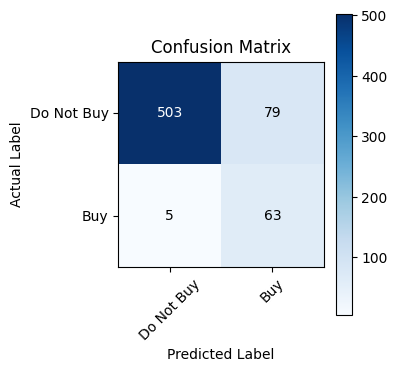

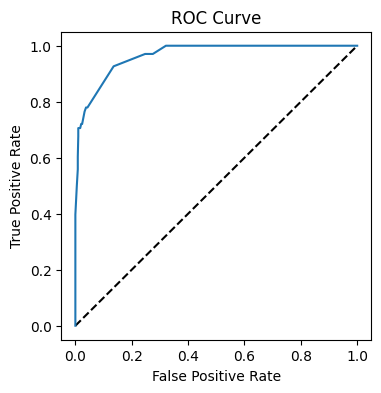

AUC: 0.9655473013947848
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 10 / min leaf: 1 / max leaf node: None
        Features   Importances
9       month_no  3.547654e-01
8      STORM_LEN  2.708086e-01
0       USA_SSHS  1.821384e-01
2        CD2LAND  1.080261e-01
3    CD2LANDFALL  5.848357e-02
5        INBOUND  1.568273e-02
6         CD2OIL  9.371190e-03
1  STORM_LOC_BIN  7.240207e-04
7        OIL_THT  4.084275e-17
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.10153846153846154
R-squared:  -0.08399029714978767
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       582
           1       0.51      1.00      0.67        68

    accuracy                           0.90       650
   macro avg       0.75      0.94      0.81       650
weighted avg       0.95      0.90      0.91       650



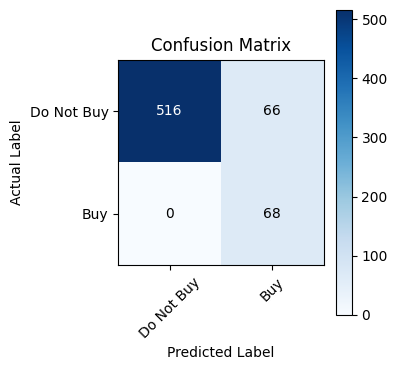

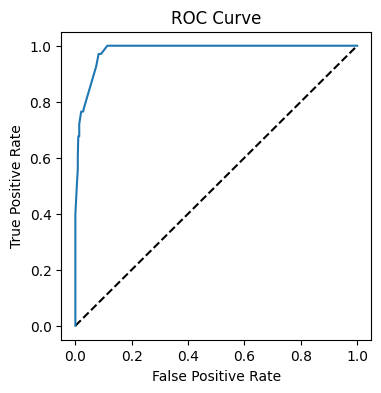

AUC: 0.9822998787143724
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 12 / min leaf: 1 / max leaf node: None
        Features   Importances
9       month_no  3.510709e-01
8      STORM_LEN  2.895726e-01
0       USA_SSHS  1.737786e-01
2        CD2LAND  1.012627e-01
3    CD2LANDFALL  6.015122e-02
5        INBOUND  1.470084e-02
6         CD2OIL  8.784463e-03
1  STORM_LOC_BIN  6.786900e-04
7        OIL_THT  3.875811e-16
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.08307692307692308
R-squared:  0.11309884778653745
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       582
           1       0.56      0.99      0.71        68

    accuracy                           0.92       650
   macro avg       0.78      0.95      0.83       650
weighted avg       0.95      0.92      0.93       650



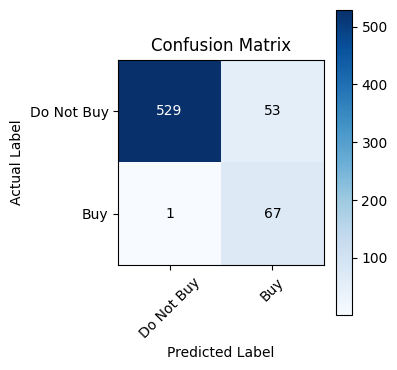

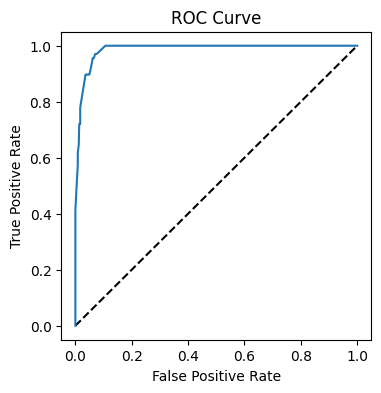

AUC: 0.9865827774408733
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 14 / min leaf: 1 / max leaf node: None
        Features   Importances
9       month_no  3.625828e-01
8      STORM_LEN  2.758648e-01
0       USA_SSHS  1.682508e-01
2        CD2LAND  9.804155e-02
3    CD2LANDFALL  6.402637e-02
5        INBOUND  2.207143e-02
6         CD2OIL  8.505034e-03
1  STORM_LOC_BIN  6.571013e-04
7        OIL_THT  3.706776e-17
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.06461538461538462
R-squared:  0.31018799272286246
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       582
           1       0.62      1.00      0.76        68

    accuracy                           0.94       650
   macro avg       0.81      0.96      0.86       650
weighted avg       0.96      0.94      0.94       650



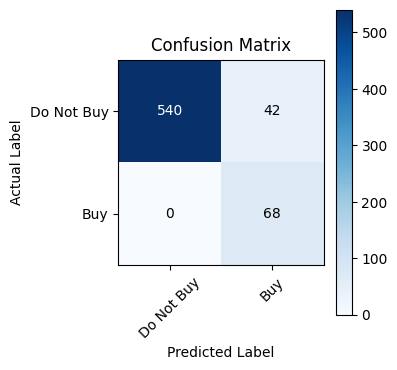

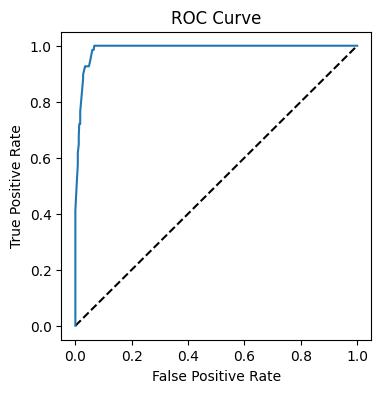

AUC: 0.9888568829593694
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 16 / min leaf: 1 / max leaf node: None
        Features   Importances
9       month_no  3.617808e-01
8      STORM_LEN  2.839227e-01
0       USA_SSHS  1.669506e-01
2        CD2LAND  9.728392e-02
3    CD2LANDFALL  5.906975e-02
5        INBOUND  2.190087e-02
6         CD2OIL  8.439310e-03
1  STORM_LOC_BIN  6.520234e-04
7        OIL_THT  3.678131e-17
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.06307692307692307
R-squared:  0.3266120881342228
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       582
           1       0.62      1.00      0.77        68

    accuracy                           0.94       650
   macro avg       0.81      0.96      0.87       650
weighted avg       0.96      0.94      0.94       650



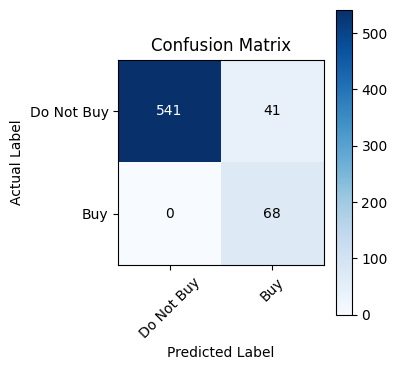

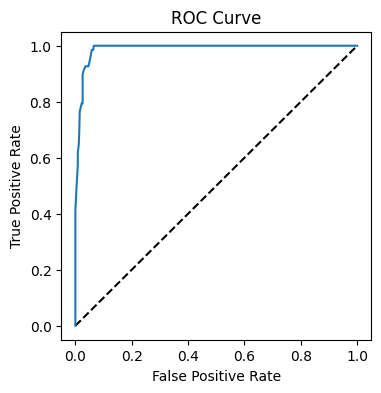

AUC: 0.9888695168789166
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: 18 / min leaf: 1 / max leaf node: None
        Features   Importances
9       month_no  3.617702e-01
8      STORM_LEN  2.807639e-01
0       USA_SSHS  1.669457e-01
2        CD2LAND  9.728107e-02
3    CD2LANDFALL  5.778611e-02
5        INBOUND  2.636195e-02
6         CD2OIL  8.439062e-03
1  STORM_LOC_BIN  6.520042e-04
7        OIL_THT  3.678023e-17
4       CD2METRO  0.000000e+00
Mean Squared Error:  0.06307692307692307
R-squared:  0.3266120881342228
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       582
           1       0.62      1.00      0.77        68

    accuracy                           0.94       650
   macro avg       0.81      0.96      0.87       650
weighted avg       0.96      0.94      0.94       650



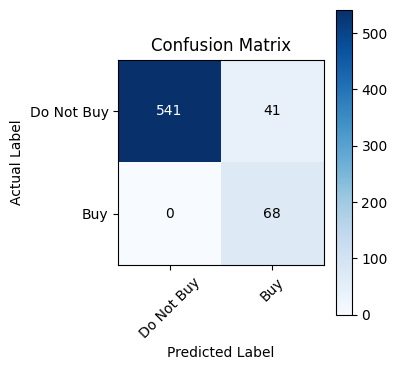

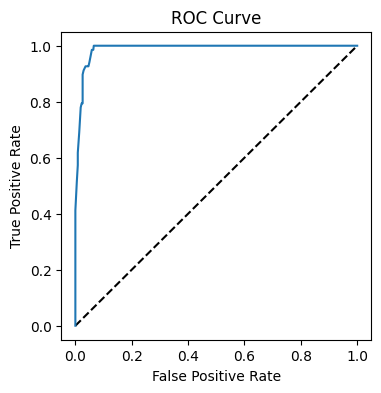

AUC: 0.9888063472811806
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 2 / max leaf node: None
        Features  Importances
9       month_no     0.394932
8      STORM_LEN     0.226391
0       USA_SSHS     0.147234
3    CD2LANDFALL     0.085525
2        CD2LAND     0.081312
5        INBOUND     0.040935
7        OIL_THT     0.013198
4       CD2METRO     0.010473
1  STORM_LOC_BIN     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



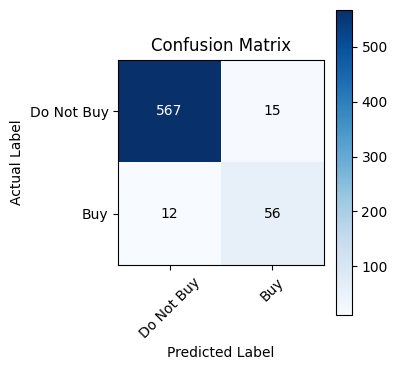

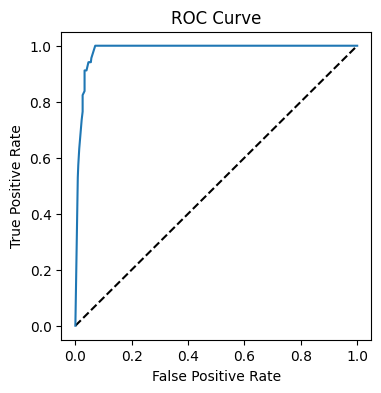

AUC: 0.9848013947847181
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 4 / max leaf node: None
        Features  Importances
9       month_no     0.398080
8      STORM_LEN     0.212712
0       USA_SSHS     0.126874
3    CD2LANDFALL     0.085478
2        CD2LAND     0.081781
5        INBOUND     0.054935
6         CD2OIL     0.016326
7        OIL_THT     0.013280
4       CD2METRO     0.010534
1  STORM_LOC_BIN     0.000000
Mean Squared Error:  0.04153846153846154
R-squared:  0.5565494238932687
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.79      0.82      0.81        68

    accuracy                           0.96       650
   macro avg       0.88      0.90      0.89       650
weighted avg       0.96      0.96      0.96       650



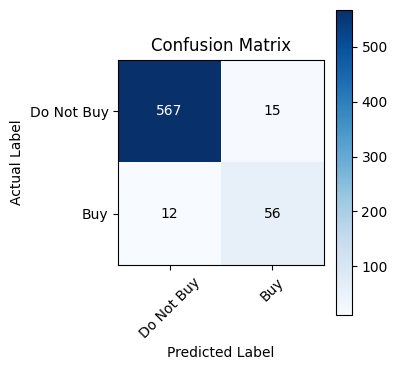

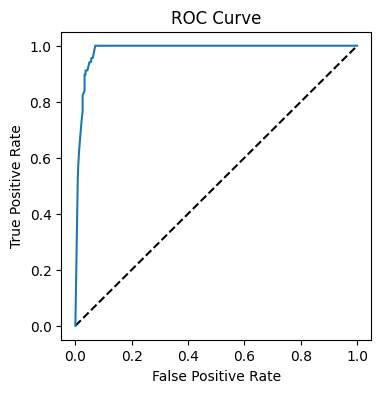

AUC: 0.9845360824742269
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 6 / max leaf node: None
        Features  Importances
9       month_no     0.400715
8      STORM_LEN     0.228512
0       USA_SSHS     0.146180
3    CD2LANDFALL     0.084466
2        CD2LAND     0.083557
5        INBOUND     0.030787
7        OIL_THT     0.013391
4       CD2METRO     0.010627
1  STORM_LOC_BIN     0.001766
6         CD2OIL     0.000000
Mean Squared Error:  0.04461538461538461
R-squared:  0.5237012330705478
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.78      0.79      0.79        68

    accuracy                           0.96       650
   macro avg       0.88      0.88      0.88       650
weighted avg       0.96      0.96      0.96       650



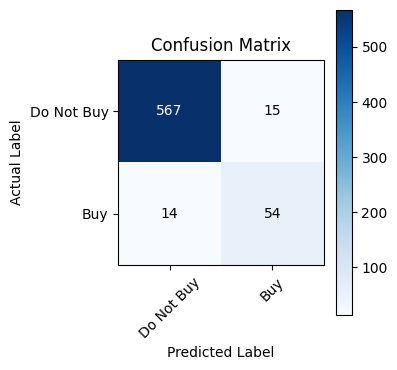

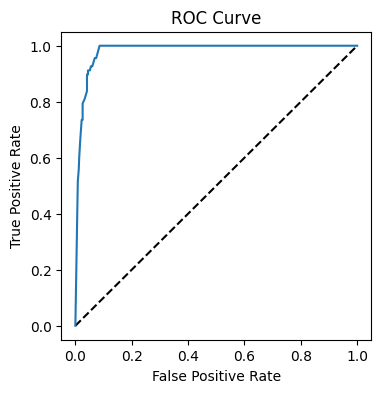

AUC: 0.9820851020820699
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 8 / max leaf node: None
        Features  Importances
9       month_no     0.419570
8      STORM_LEN     0.218952
0       USA_SSHS     0.139620
2        CD2LAND     0.086912
3    CD2LANDFALL     0.086786
5        INBOUND     0.032768
7        OIL_THT     0.015391
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.04461538461538461
R-squared:  0.5237012330705478
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       582
           1       0.78      0.79      0.79        68

    accuracy                           0.96       650
   macro avg       0.88      0.88      0.88       650
weighted avg       0.96      0.96      0.96       650



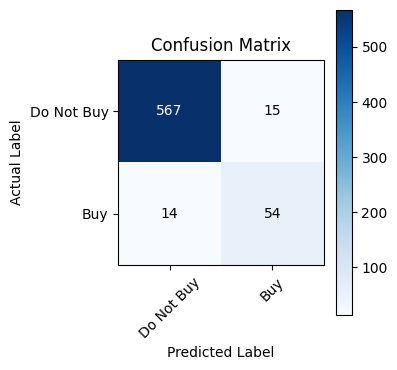

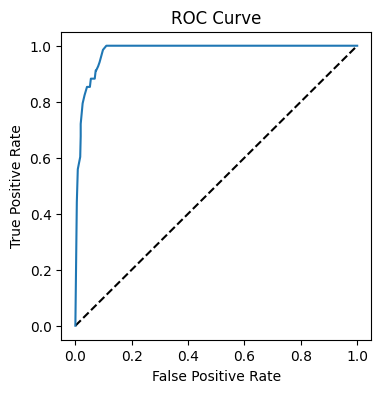

AUC: 0.9801521123913483
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 10 / max leaf node: None
        Features  Importances
9       month_no     0.417993
8      STORM_LEN     0.234186
0       USA_SSHS     0.133173
2        CD2LAND     0.092720
3    CD2LANDFALL     0.083161
5        INBOUND     0.019246
7        OIL_THT     0.015049
1  STORM_LOC_BIN     0.004472
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       582
           1       0.71      0.79      0.75        68

    accuracy                           0.94       650
   macro avg       0.84      0.88      0.86       650
weighted avg       0.95      0.94      0.95       650



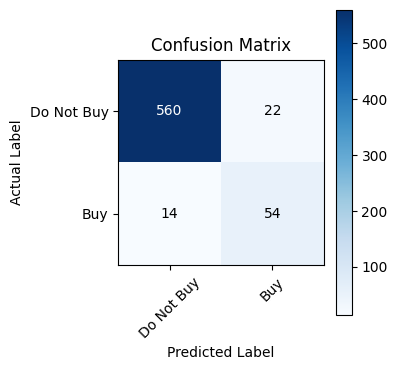

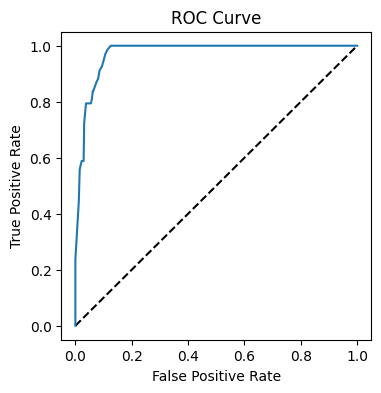

AUC: 0.9727107337780473
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 12 / max leaf node: None
        Features  Importances
9       month_no     0.419743
8      STORM_LEN     0.226237
0       USA_SSHS     0.138190
2        CD2LAND     0.102814
3    CD2LANDFALL     0.083707
7        OIL_THT     0.015148
5        INBOUND     0.014161
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       582
           1       0.71      0.79      0.75        68

    accuracy                           0.94       650
   macro avg       0.84      0.88      0.86       650
weighted avg       0.95      0.94      0.95       650



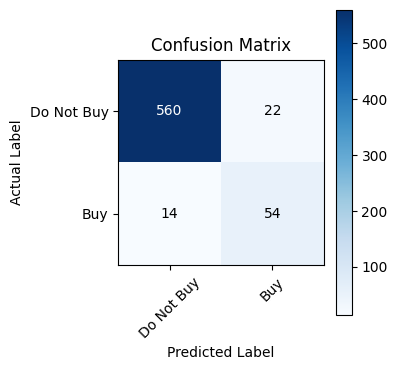

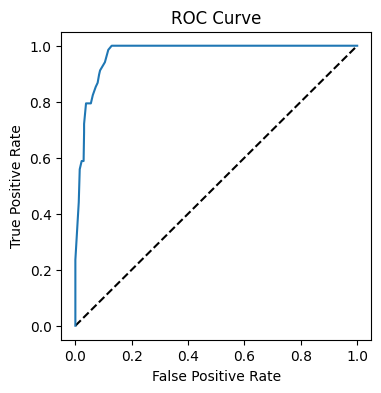

AUC: 0.9720664038811401
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 14 / max leaf node: None
        Features  Importances
9       month_no     0.407864
8      STORM_LEN     0.239066
0       USA_SSHS     0.139489
2        CD2LAND     0.096277
3    CD2LANDFALL     0.082199
5        INBOUND     0.019140
7        OIL_THT     0.015965
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.06615384615384616
R-squared:  0.293763897311502
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       582
           1       0.70      0.65      0.67        68

    accuracy                           0.93       650
   macro avg       0.83      0.81      0.82       650
weighted avg       0.93      0.93      0.93       650



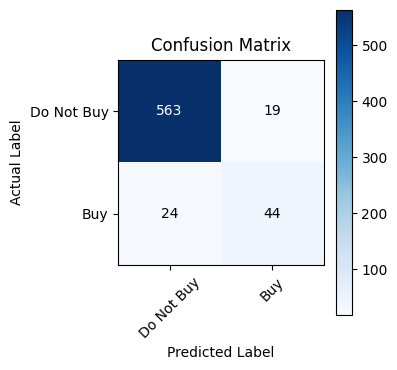

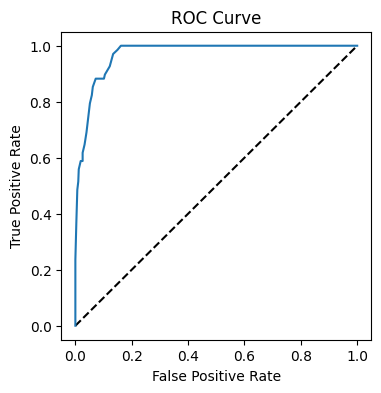

AUC: 0.9698428340408328
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 16 / max leaf node: None
        Features  Importances
9       month_no     0.443878
8      STORM_LEN     0.221397
0       USA_SSHS     0.105554
3    CD2LANDFALL     0.086532
2        CD2LAND     0.085350
5        INBOUND     0.041497
7        OIL_THT     0.015792
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05384615384615385
R-squared:  0.42515666060238533
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.69      0.73        68

    accuracy                           0.95       650
   macro avg       0.87      0.83      0.85       650
weighted avg       0.94      0.95      0.94       650



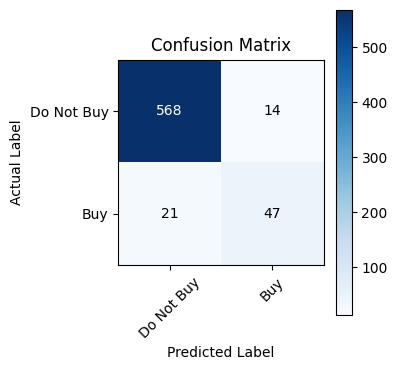

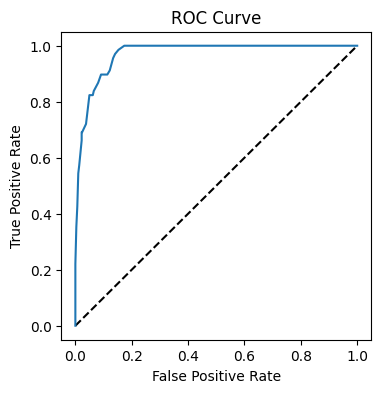

AUC: 0.9707903780068727
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 18 / max leaf node: None
        Features  Importances
9       month_no     0.459353
8      STORM_LEN     0.202822
0       USA_SSHS     0.114488
2        CD2LAND     0.089741
3    CD2LANDFALL     0.069933
5        INBOUND     0.047058
7        OIL_THT     0.016605
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05692307692307692
R-squared:  0.3923084697796645
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.65      0.70        68

    accuracy                           0.94       650
   macro avg       0.87      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



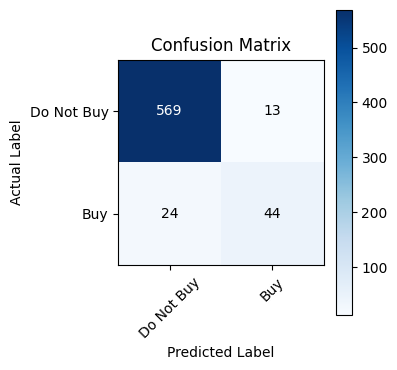

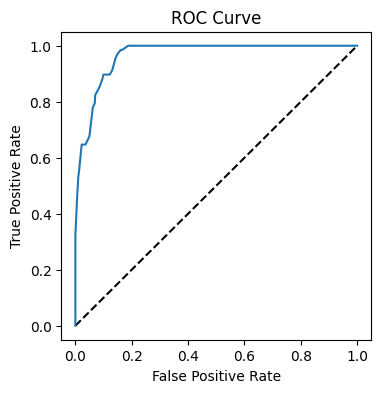

AUC: 0.9656862745098039
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 2
        Features  Importances
9       month_no          1.0
0       USA_SSHS          0.0
1  STORM_LOC_BIN          0.0
2        CD2LAND          0.0
4       CD2METRO          0.0
3    CD2LANDFALL          0.0
5        INBOUND          0.0
6         CD2OIL          0.0
7        OIL_THT          0.0
8      STORM_LEN          0.0
Mean Squared Error:  0.09384615384615384
R-squared:  -0.0018698200929856412
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       582
           1       0.59      0.35      0.44        68

    accuracy                           0.91       650
   macro avg       0.76      0.66      0.69       650
weighted avg       0.89      0.91      0.90       650



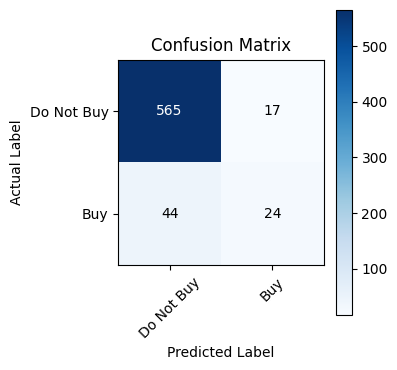

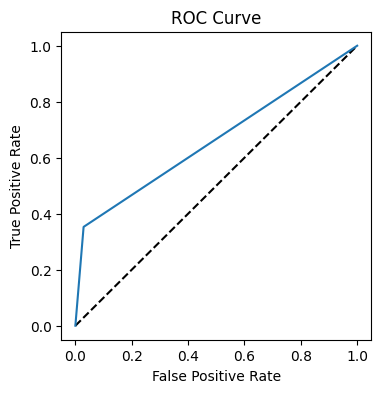

AUC: 0.6618657772387305
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 4
        Features  Importances
9       month_no     0.875688
2        CD2LAND     0.124312
1  STORM_LOC_BIN     0.000000
0       USA_SSHS     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
7        OIL_THT     0.000000
8      STORM_LEN     0.000000
Mean Squared Error:  0.09384615384615384
R-squared:  -0.0018698200929856412
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       582
           1       0.59      0.35      0.44        68

    accuracy                           0.91       650
   macro avg       0.76      0.66      0.69       650
weighted avg       0.89      0.91      0.90       650



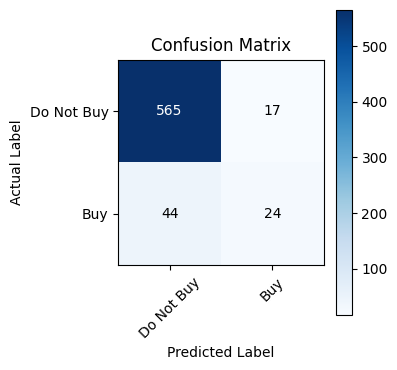

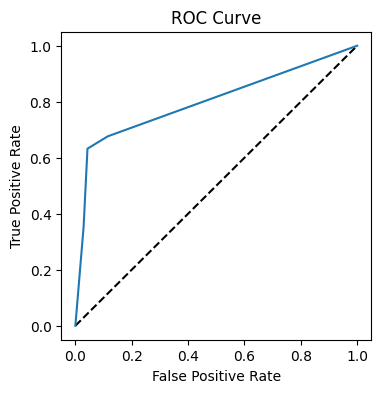

AUC: 0.8008894279361229
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 6
        Features  Importances
9       month_no     0.739819
2        CD2LAND     0.105024
8      STORM_LEN     0.089048
0       USA_SSHS     0.066109
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.07384615384615385
R-squared:  0.21164342025469995
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       582
           1       0.66      0.60      0.63        68

    accuracy                           0.93       650
   macro avg       0.81      0.78      0.79       650
weighted avg       0.92      0.93      0.92       650



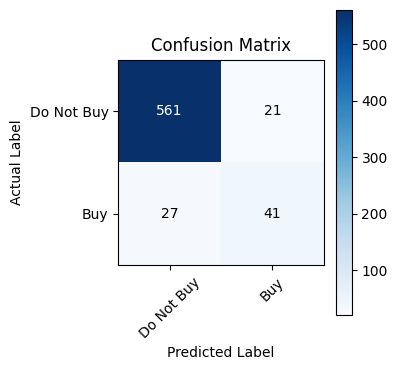

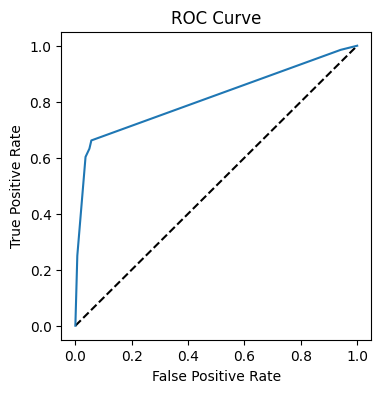

AUC: 0.8129674550232464
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 8
        Features  Importances
9       month_no     0.670825
2        CD2LAND     0.147956
8      STORM_LEN     0.121276
0       USA_SSHS     0.059944
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.07384615384615385
R-squared:  0.21164342025469995
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       582
           1       0.66      0.60      0.63        68

    accuracy                           0.93       650
   macro avg       0.81      0.78      0.79       650
weighted avg       0.92      0.93      0.92       650



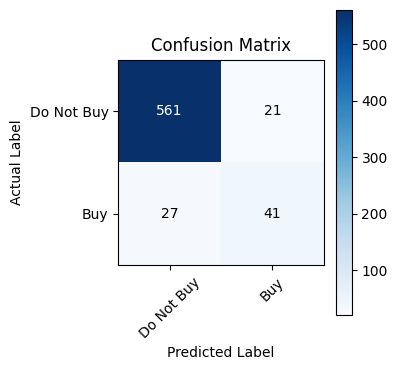

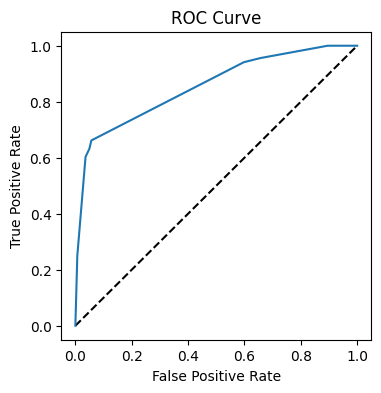

AUC: 0.8538255508388923
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 10
        Features  Importances
9       month_no     0.628589
2        CD2LAND     0.138640
8      STORM_LEN     0.113640
0       USA_SSHS     0.093477
7        OIL_THT     0.025653
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.77      0.63      0.69        68

    accuracy                           0.94       650
   macro avg       0.86      0.81      0.83       650
weighted avg       0.94      0.94      0.94       650



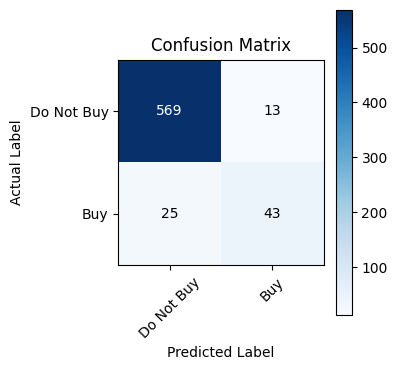

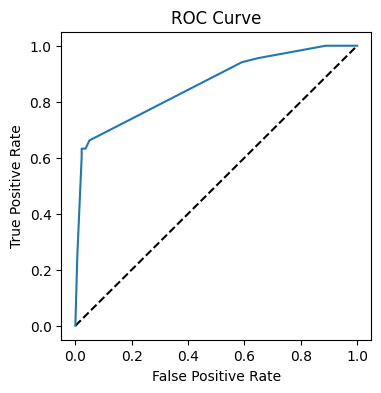

AUC: 0.8594855467960381
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 12
        Features  Importances
9       month_no     0.578822
8      STORM_LEN     0.183816
2        CD2LAND     0.127664
0       USA_SSHS     0.086076
7        OIL_THT     0.023622
1  STORM_LOC_BIN     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
3    CD2LANDFALL     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.055384615384615386
R-squared:  0.40873256519102497
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       582
           1       0.80      0.63      0.70        68

    accuracy                           0.94       650
   macro avg       0.88      0.81      0.84       650
weighted avg       0.94      0.94      0.94       650



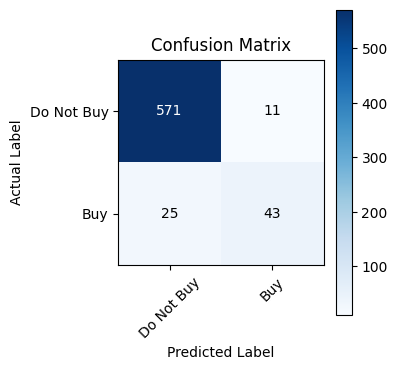

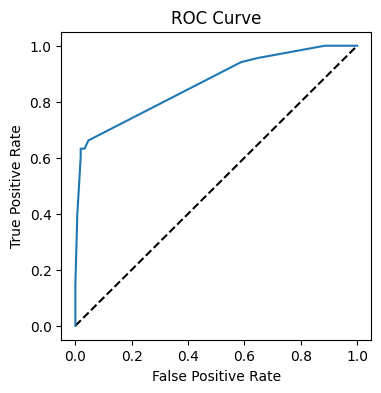

AUC: 0.8633515261774813
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 14
        Features  Importances
9       month_no     0.547518
8      STORM_LEN     0.195236
2        CD2LAND     0.120759
0       USA_SSHS     0.081421
3    CD2LANDFALL     0.032721
7        OIL_THT     0.022344
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       582
           1       0.83      0.56      0.67        68

    accuracy                           0.94       650
   macro avg       0.89      0.77      0.82       650
weighted avg       0.94      0.94      0.94       650



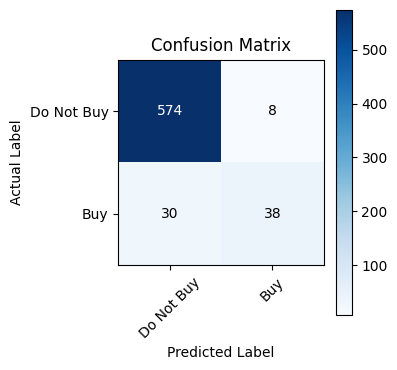

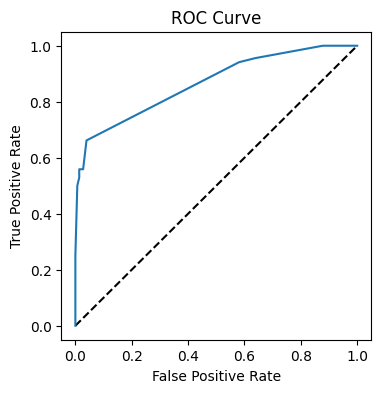

AUC: 0.8658909440064686
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 16
        Features  Importances
9       month_no     0.520492
8      STORM_LEN     0.216559
2        CD2LAND     0.114799
0       USA_SSHS     0.095802
3    CD2LANDFALL     0.031106
7        OIL_THT     0.021241
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.05846153846153846
R-squared:  0.37588437436830413
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       582
           1       0.83      0.56      0.67        68

    accuracy                           0.94       650
   macro avg       0.89      0.77      0.82       650
weighted avg       0.94      0.94      0.94       650



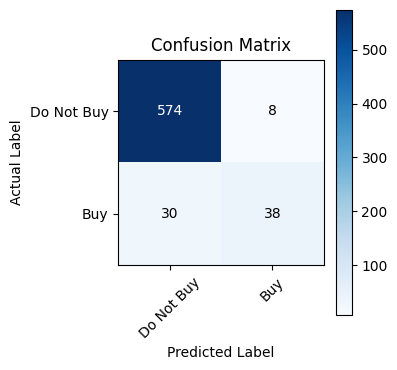

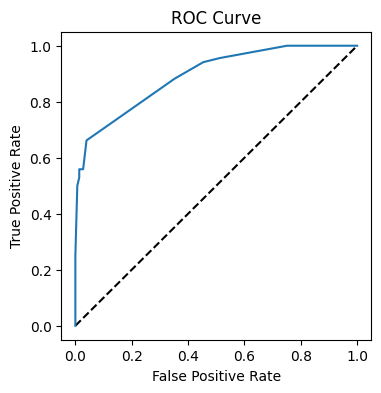

AUC: 0.8931170406306852
Balanced Model: model_all_avg (1) / Response: buy_avg / max level: None / min leaf: 1 / max leaf node: 18
        Features  Importances
9       month_no     0.501602
8      STORM_LEN     0.226078
2        CD2LAND     0.110632
0       USA_SSHS     0.092325
3    CD2LANDFALL     0.048891
7        OIL_THT     0.020470
1  STORM_LOC_BIN     0.000000
4       CD2METRO     0.000000
5        INBOUND     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.06
R-squared:  0.35946027895694366
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       582
           1       0.80      0.57      0.67        68

    accuracy                           0.94       650
   macro avg       0.87      0.78      0.82       650
weighted avg       0.94      0.94      0.94       650



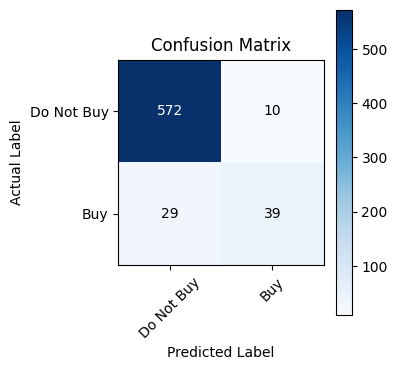

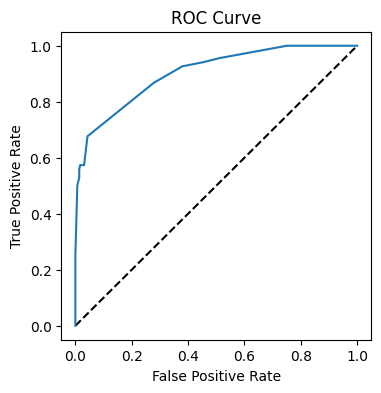

AUC: 0.9032494441075399
       data_model  max_lvl  leaf  leafnode       mse        r2       acc  \
0   model_all_avg      2.0     1       NaN  0.133846 -0.428896  0.866154   
1   model_all_avg      4.0     1       NaN  0.067692  0.277340  0.932308   
2   model_all_avg      6.0     1       NaN  0.063077  0.326612  0.936923   
3   model_all_avg      8.0     1       NaN  0.129231 -0.379624  0.870769   
4   model_all_avg     10.0     1       NaN  0.101538 -0.083990  0.898462   
5   model_all_avg     12.0     1       NaN  0.083077  0.113099  0.916923   
6   model_all_avg     14.0     1       NaN  0.064615  0.310188  0.935385   
7   model_all_avg     16.0     1       NaN  0.063077  0.326612  0.936923   
8   model_all_avg     18.0     1       NaN  0.063077  0.326612  0.936923   
9   model_all_avg      NaN     2       NaN  0.041538  0.556549  0.958462   
10  model_all_avg      NaN     4       NaN  0.041538  0.556549  0.958462   
11  model_all_avg      NaN     6       NaN  0.044615  0.523701  

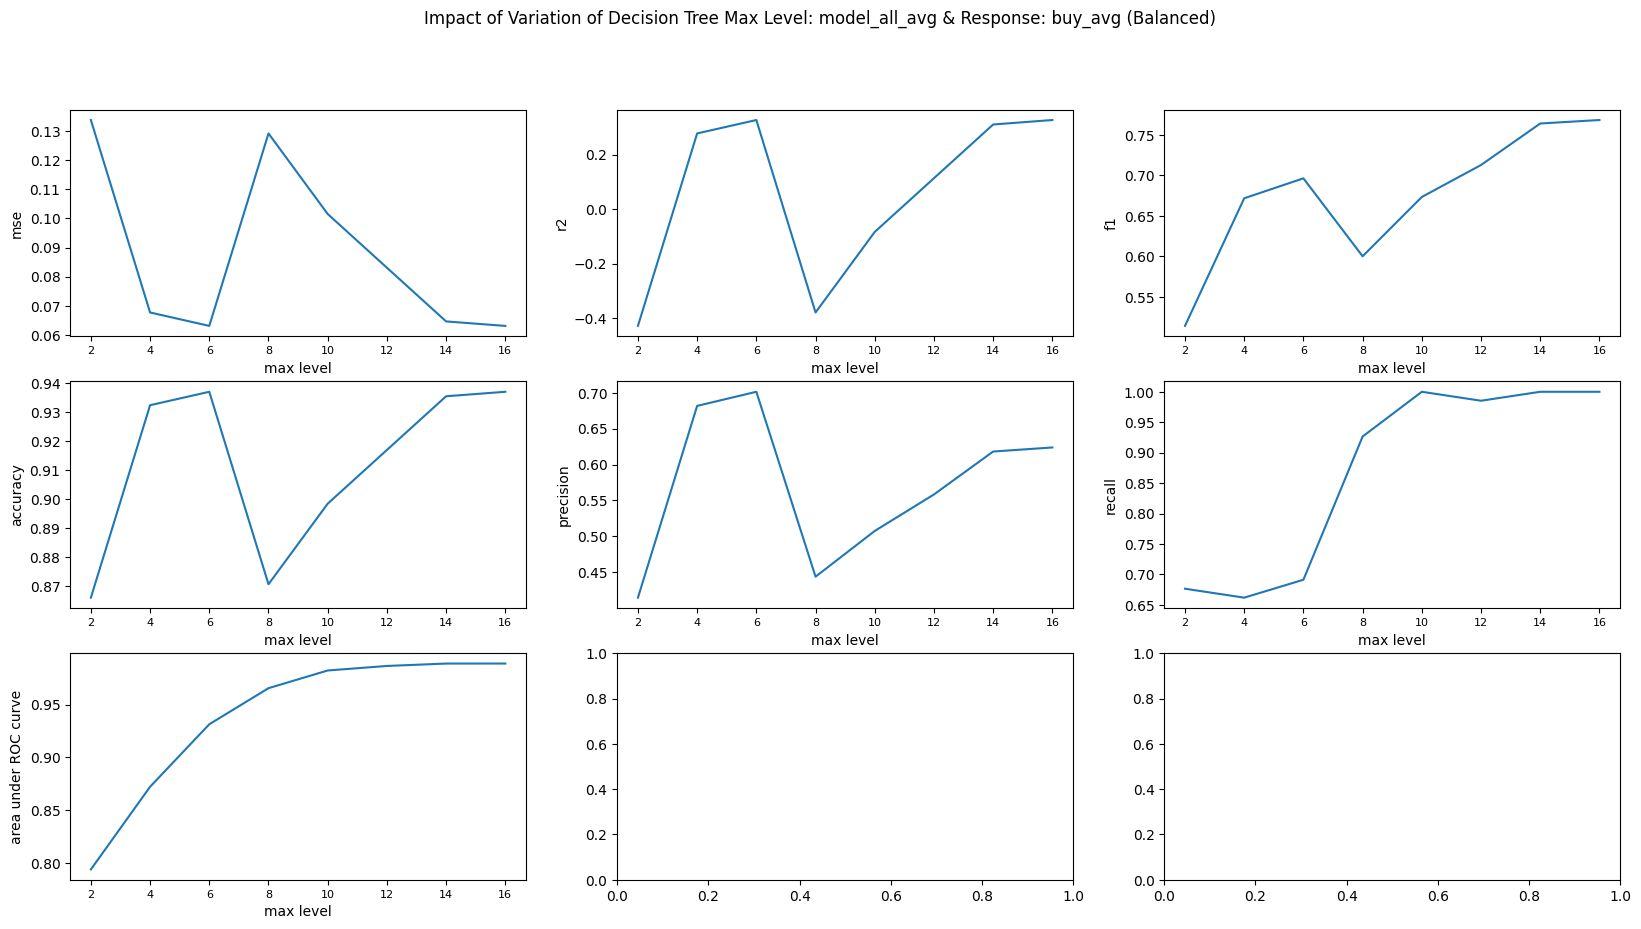

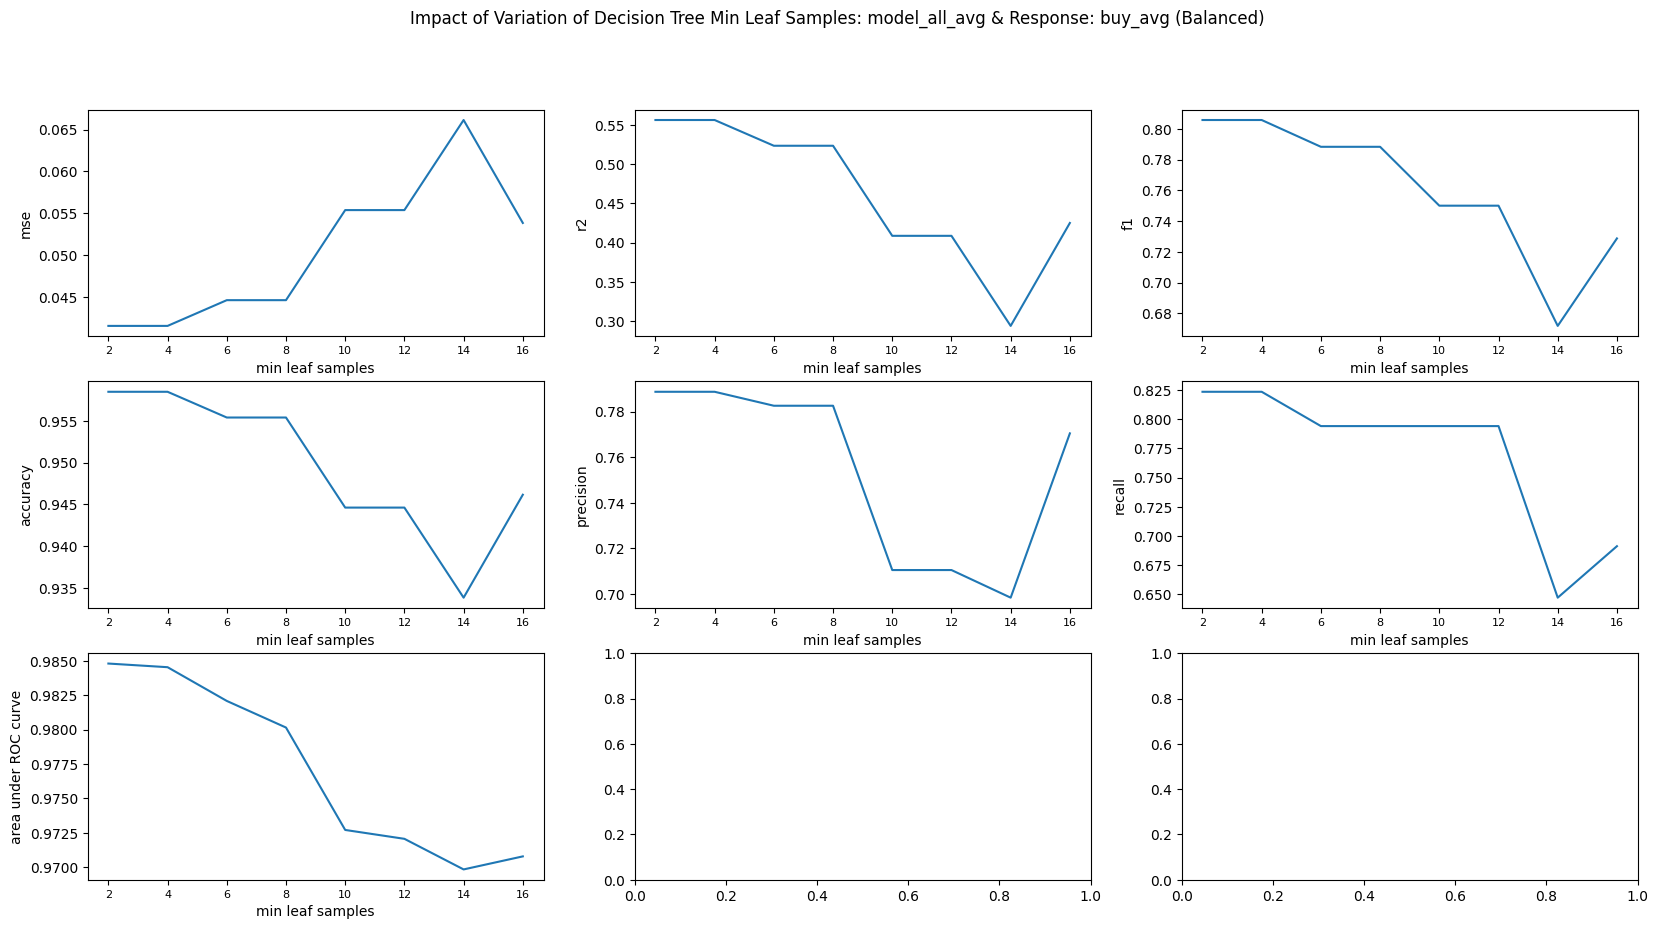

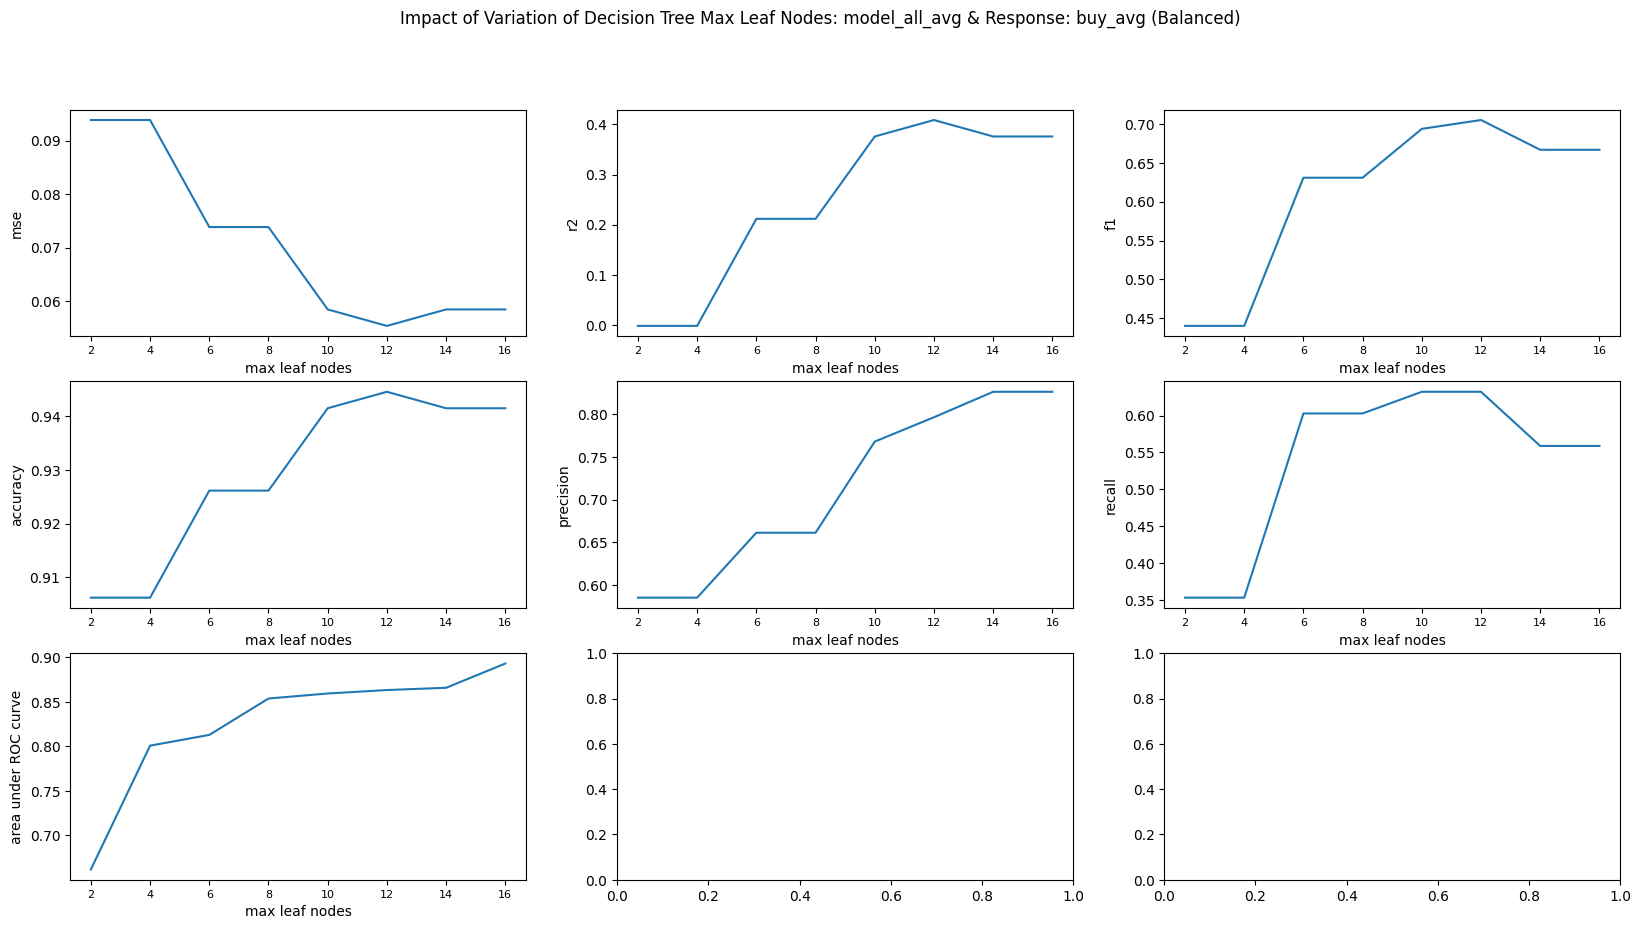

In [20]:
model_list = [model_all_avg]
model_names = ['model_all_avg']

model_dec_tree_bal_hyp_par_eval(model_list, model_names,class_list,'buy_avg', None, 1, None,0)

        Features  Importances
9       month_no     0.523881
8      STORM_LEN     0.201413
0       USA_SSHS     0.139488
2        CD2LAND     0.135217
1  STORM_LOC_BIN     0.000000
3    CD2LANDFALL     0.000000
5        INBOUND     0.000000
4       CD2METRO     0.000000
7        OIL_THT     0.000000
6         CD2OIL     0.000000
Mean Squared Error:  0.08
R-squared:  0.14594703860925828
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       582
           1       0.61      0.66      0.63        68

    accuracy                           0.92       650
   macro avg       0.78      0.81      0.79       650
weighted avg       0.92      0.92      0.92       650



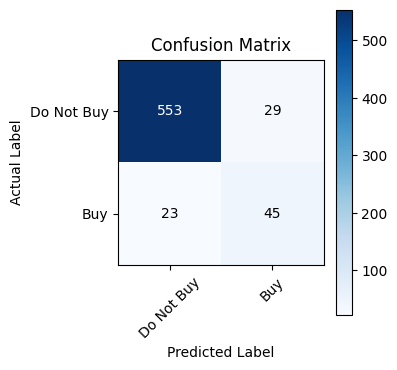

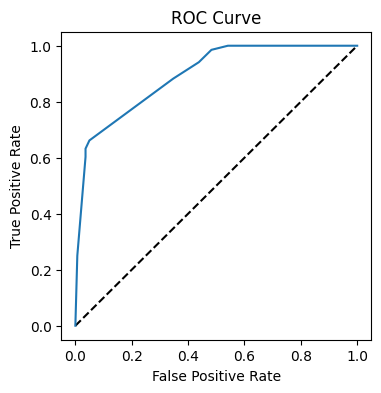

AUC: 0.8945194057004245


In [21]:
model = model_all_avg
y_param = 'buy_avg'
max_lvls = 6
min_leaf_samp = 3
max_leaf_nod = 12

X_train_bal, X_test_bal, y_train_bal, y_test_bal, X_train, X_test, y_train, y_test, features_list = model_setup(
    model, y_param, testsplit=0.2, stratify_set = True)

mod_dtb, y_pred, feat_list, feat_imp = model_dec_tree_bal(X_train_bal, X_test, y_train_bal,
                                                          features_list, max_lvls, min_leaf_samp, max_leaf_nod)

mse, r2, acc_sc, prec_sc, rec_sc, f1_sc, auc_sc = model_stats_analysis(y_test, y_pred, X_test, mod_dtb)


In [22]:
# Random Forest

In [23]:
model_all_avg

,USA_SSHS,STORM_LOC_BIN,CD2LAND,CD2LANDFALL,CD2METRO,INBOUND,CD2OIL,OIL_THT,STORM_LEN,month_no,buy_avg
0,-3,1,2,2,2,1,2,0,0,6,0
1,-3,1,2,2,2,1,2,0,1,6,0
2,-3,1,1,1,2,1,2,0,2,6,0
3,-3,1,1,1,2,0,2,0,3,6,0
4,0,1,1,1,2,0,2,0,4,7,0
...,...,...,...,...,...,...,...,...,...,...,...
3244,5,1,1,1,2,0,2,0,10,10,0
3245,5,1,1,1,2,0,2,0,11,10,0
3246,2,1,1,1,2,0,2,0,12,10,0
3247,2,1,2,3,2,0,2,0,13,10,0


Out-of-Bag Score:  0.9442093112735668
        Features  Importances
9       month_no     0.567157
8      STORM_LEN     0.126310
0       USA_SSHS     0.085275
3    CD2LANDFALL     0.065739
1  STORM_LOC_BIN     0.046020
2        CD2LAND     0.045189
7        OIL_THT     0.030760
5        INBOUND     0.021994
6         CD2OIL     0.006489
4       CD2METRO     0.005068
Number of trees in random forest: 100
Mean Squared Error:  0.05384615384615385
R-squared:  0.42515666060238533
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       582
           1       0.87      0.57      0.69        68

    accuracy                           0.95       650
   macro avg       0.91      0.78      0.83       650
weighted avg       0.94      0.95      0.94       650



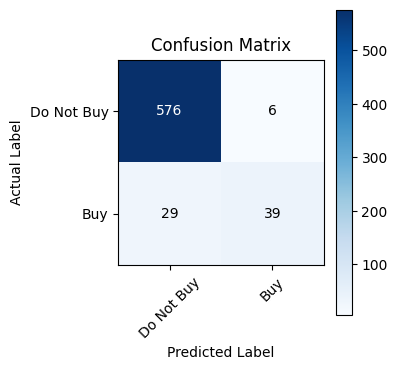

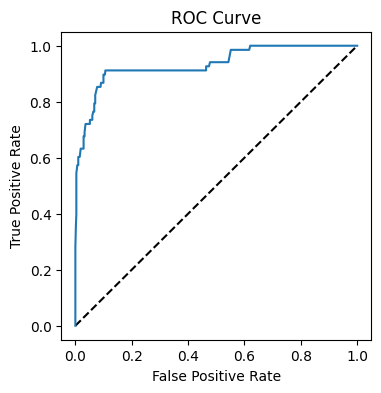

AUC: 0.9339372346876895


In [24]:
# Random Forest

rf_results = []

dat = []
oob = []
mse = []
r2 = []
acc = []
prec = []
rec = []
f1 = []

node_est = 100
max_lvls = 5
min_leaf_samp = 3
max_leaf_nod = 12
min_samp_splt = 2

model_rf = model_all_avg
y_param = 'buy_avg'

X_train, X_test, y_train, y_test, features_list = model_setup(model_rf,y_param,testsplit = 0.2, stratify_set = False)

mod_rf, y_pred, oob_score, feat_list, feat_imp = model_rand_forest(X_train, X_test, y_train, y_test, y_param, features_list, node_est, max_lvls, min_leaf_samp, min_samp_splt)

mse, r2, acc_sc, prec_sc, rec_sc, f1_sc, auc_sc = model_stats_analysis(y_test,y_pred,X_test,mod_rf)




In [25]:
# Evaluating decision tree with data set used for cluster and frequent pattern modeling
# buy decision based on increase in gas price over the course of a storm
data_file_miami = "../data/storm_df.csv"
df_miami = df_import(data_file_miami)

df_miami['buy'] = np.where(df_miami['gas_pct_change'] > 0, 1, 0)

df_miami.drop(columns = ['Unnamed: 0','NAME','gas_pct_change'], inplace = True)

#df_miami.head()

Successfully loaded ../data/storm_df.csv


         Features  Importances
3  STORM DURATION     0.450863
0     start_month     0.201760
2         MAX CAT     0.192437
1       end_month     0.154940
Mean Squared Error:  0.14285714285714285
R-squared:  0.41666666666666663
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.80      1.00      0.89         4

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



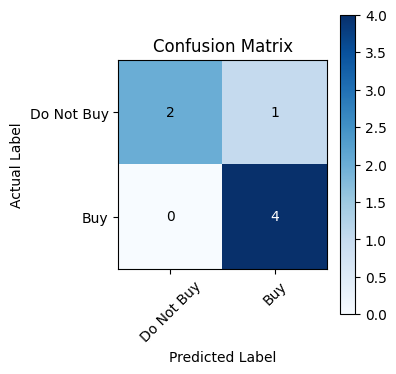

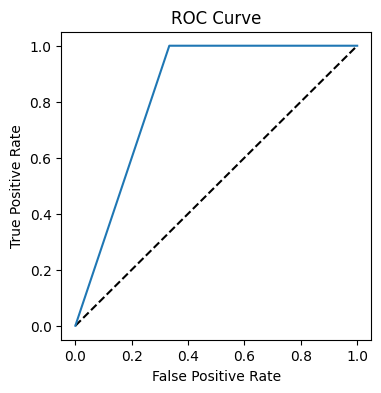

AUC: 0.8333333333333334


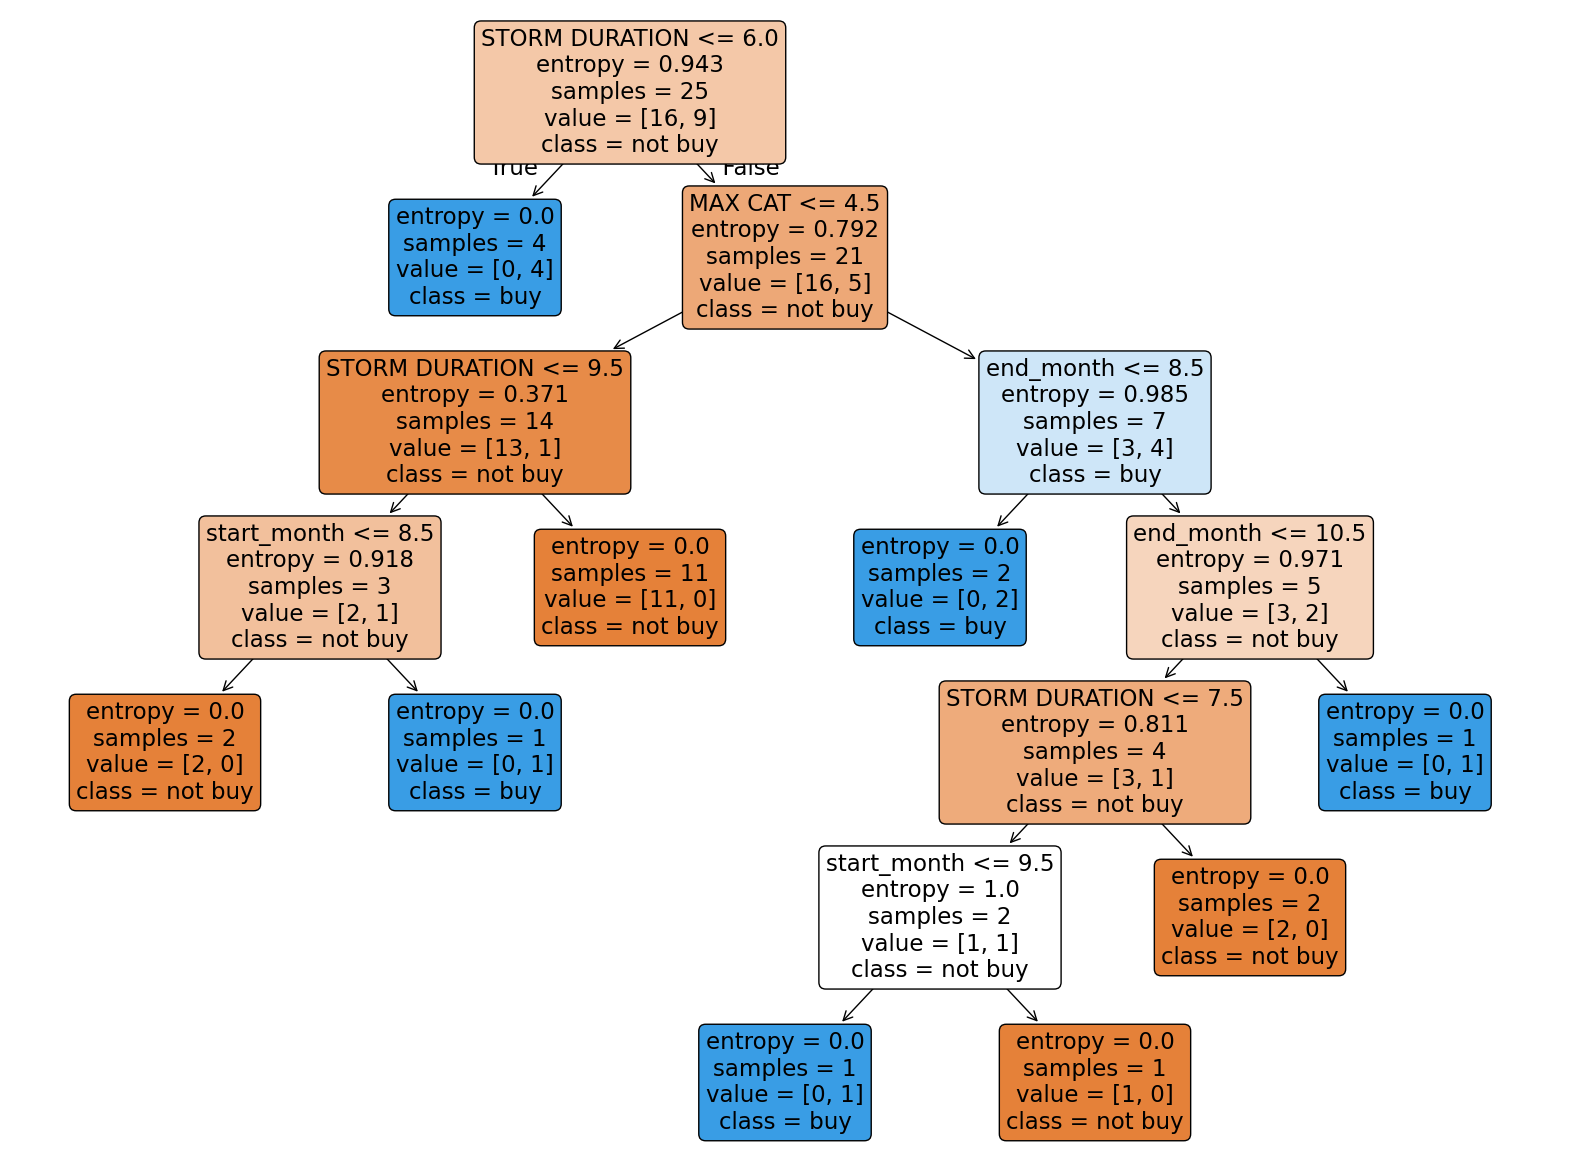

In [26]:
dec_tree_std(df_miami, 'buy', class_list, 0.2, None, 1, None)

In [27]:
# buy decision based on greater than 2% increase in gas price over the course of a storm
df_miami2 = df_import(data_file_miami)
df_miami2['buy'] = np.where(df_miami2['gas_pct_change'] > 2, 1, 0)

df_miami2.drop(columns = ['Unnamed: 0','NAME','gas_pct_change'], inplace = True)

Successfully loaded ../data/storm_df.csv


         Features  Importances
1       end_month     0.588570
3  STORM DURATION     0.218782
2         MAX CAT     0.192648
0     start_month     0.000000
Mean Squared Error:  0.14285714285714285
R-squared:  -0.1666666666666663
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.50      1.00      0.67         1

    accuracy                           0.86         7
   macro avg       0.75      0.92      0.79         7
weighted avg       0.93      0.86      0.87         7



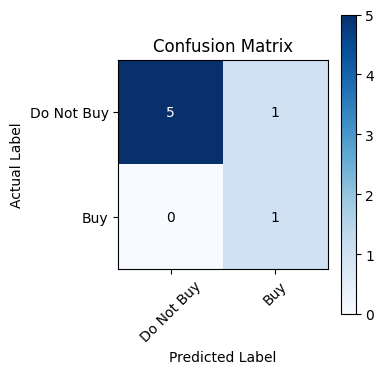

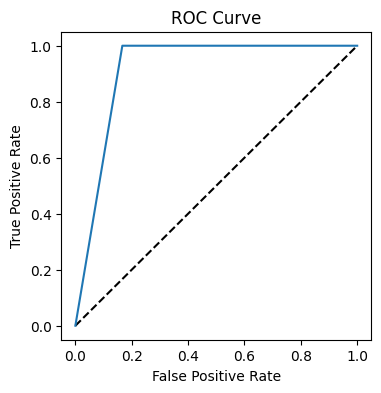

AUC: 0.9166666666666667


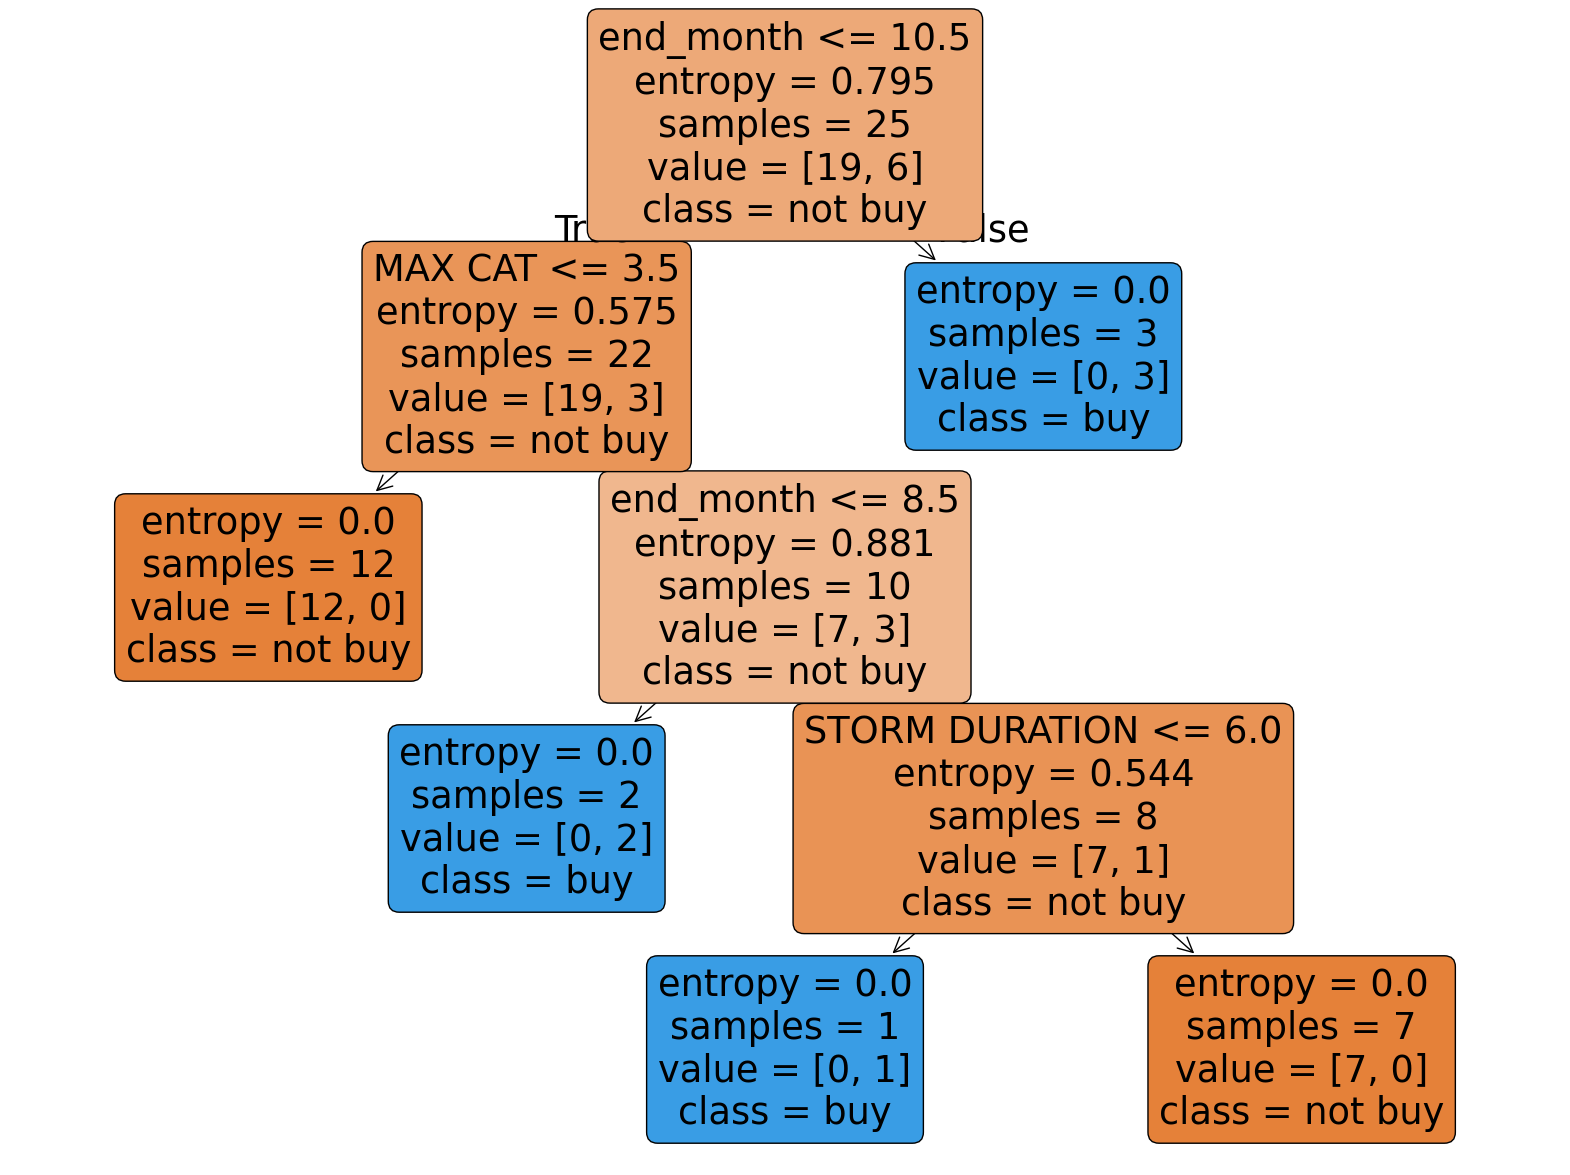

In [28]:
dec_tree_std(df_miami2, 'buy', class_list, 0.2, None, 1, None)

In [29]:
# Take a similar approach to data set but for all metro areas to increase size of data set
data_for_dt = dataset_metro_sum(hurr_mod_data, gas_data_redux)

      Features  Importances
1     Duration     0.503388
3    End Month     0.303486
0      Max Cat     0.164039
2  Start Month     0.029087
Mean Squared Error:  0.10344827586206896
R-squared:  0.5781818181818182
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.91      0.84      0.88        25

    accuracy                           0.90        58
   macro avg       0.90      0.89      0.89        58
weighted avg       0.90      0.90      0.90        58



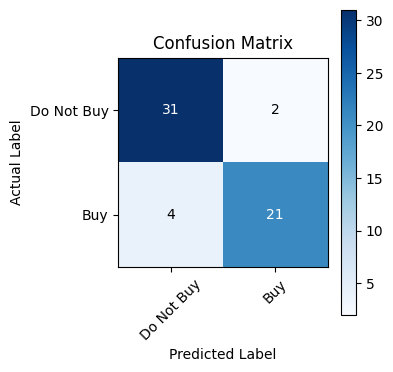

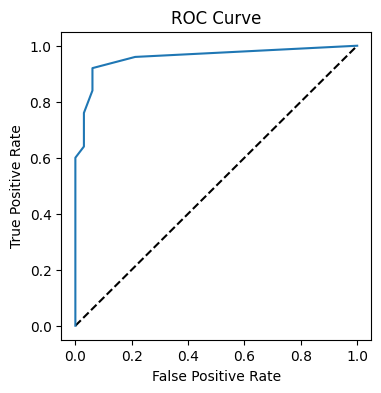

AUC: 0.9575757575757575


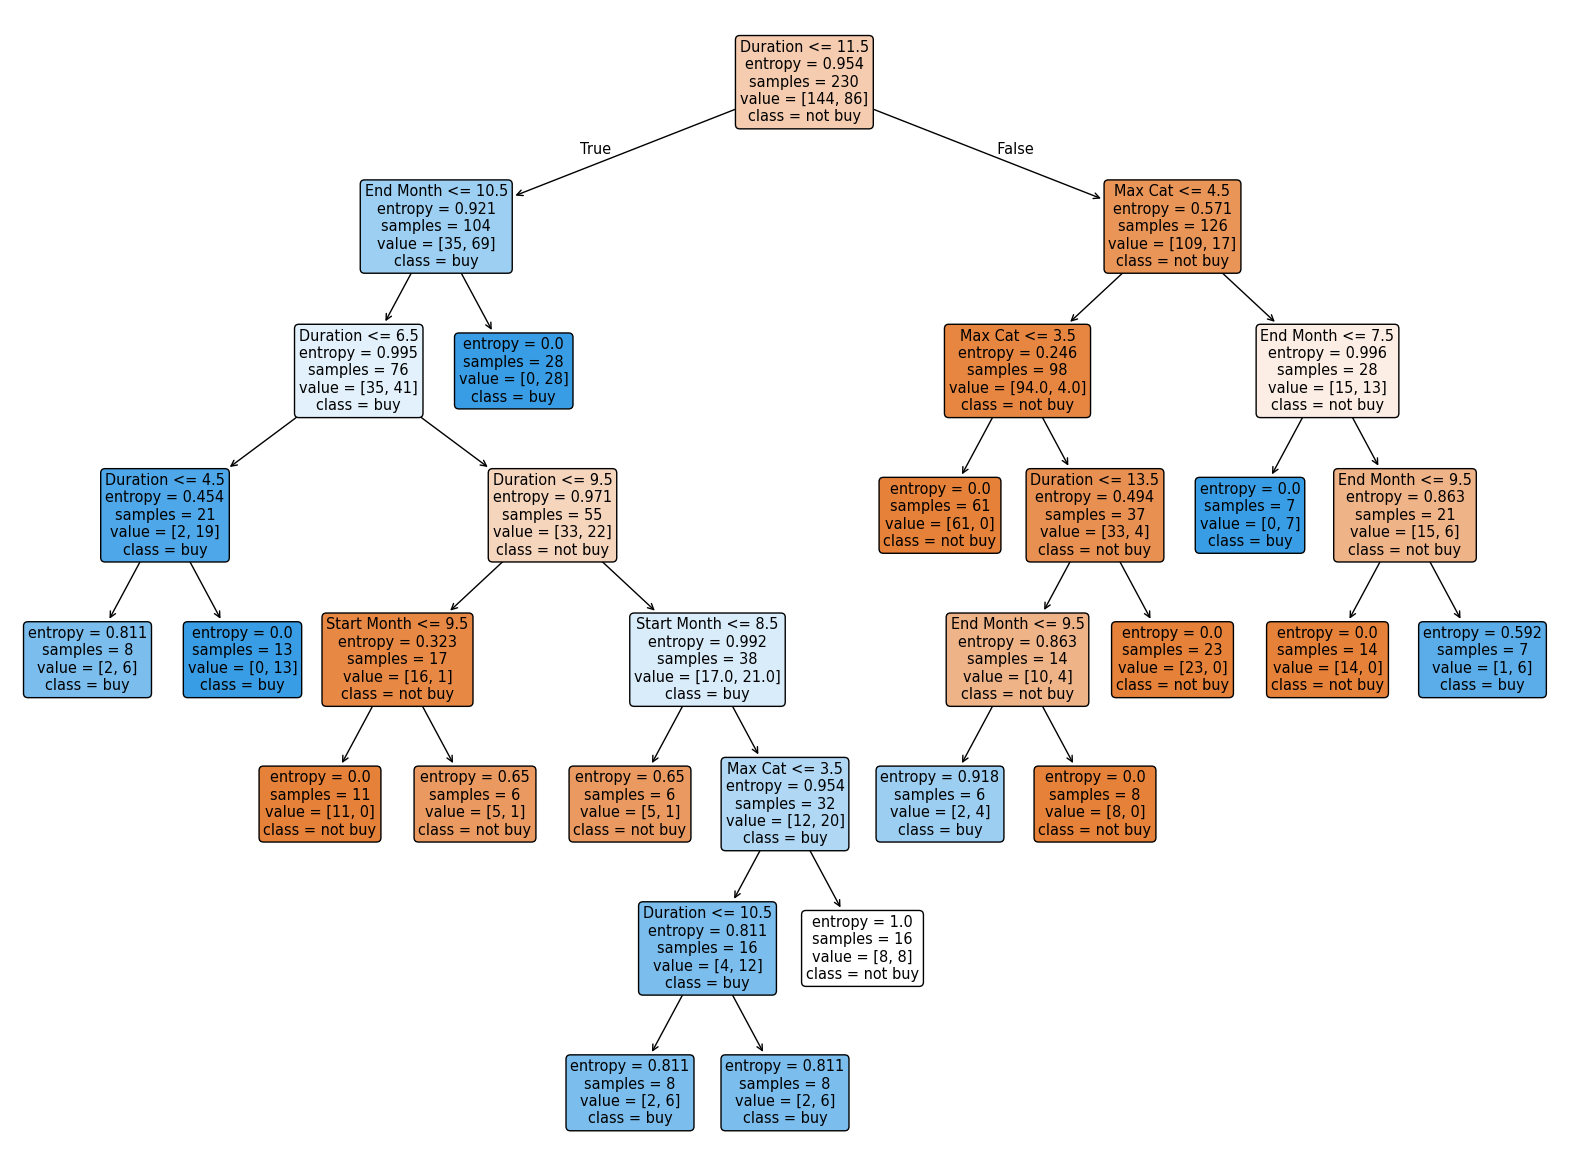

In [30]:
dec_tree_std(data_for_dt, 'buy', class_list, 0.2, None, 1, None)

      Features  Importances
1     Duration     0.503864
3    End Month     0.187249
0      Max Cat     0.160627
2  Start Month     0.148260
Mean Squared Error:  0.06896551724137931
R-squared:  0.7187878787878788
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        33
           1       0.92      0.92      0.92        25

    accuracy                           0.93        58
   macro avg       0.93      0.93      0.93        58
weighted avg       0.93      0.93      0.93        58



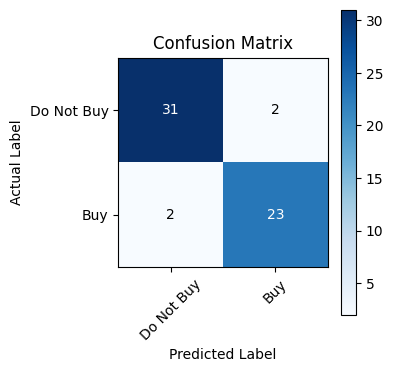

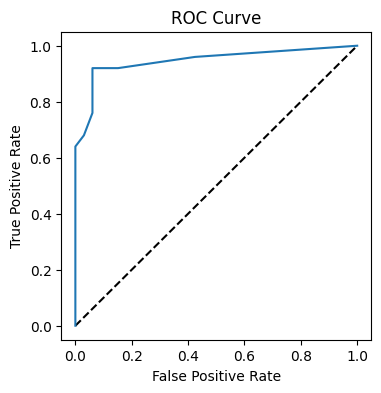

AUC: 0.946060606060606


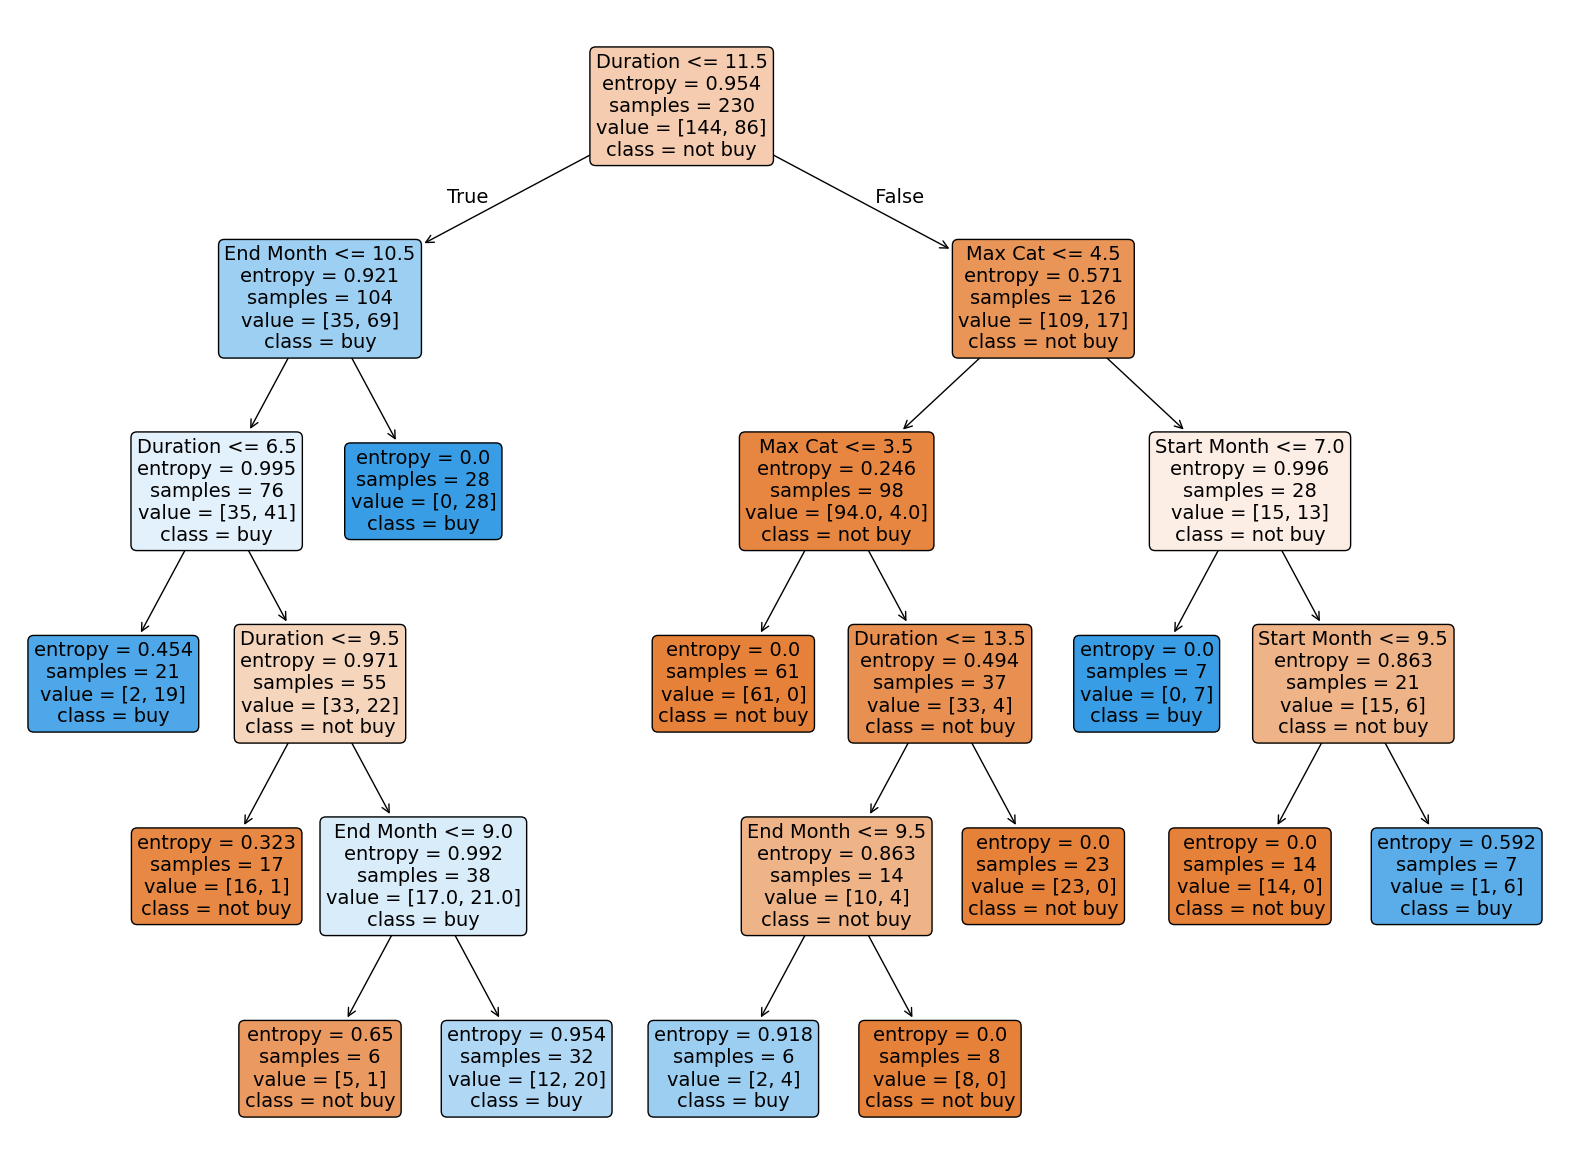

In [31]:
# apply the previously identified decision tree hyperparameters
dec_tree_std(data_for_dt, 'buy', class_list, 0.2, 5, 3, 12)